In [8]:

import pandas as pd
import os

# Path to extracted folder
data_path = r"C:\Users\Sania\Downloads\archive"

# Load all CSVs
crop_df = pd.read_csv(os.path.join(data_path, "crop_yield.csv"))
soil_df = pd.read_csv(os.path.join(data_path, "state_soil_data.csv"))
weather_df = pd.read_csv(os.path.join(data_path, "state_weather_data_1997_2020.csv"))

# Clean column names
for df in [crop_df, soil_df, weather_df]:
    df.rename(columns=lambda x: x.strip().lower().replace(" ", "_"), inplace=True)

# Merge step by step
merged_df = crop_df.merge(soil_df, on="state", how="inner")
final_df = merged_df.merge(weather_df, on=["state","year"], how="inner")

print("Final dataset shape:", final_df.shape)
print(final_df.head())

# Select numeric columns for correlation
numeric_df = final_df.select_dtypes(include=['float64','int64'])
corr_matrix = numeric_df.corr()

print("\nCorrelation with yield:")
print(corr_matrix["yield"].sort_values(ascending=False))



Final dataset shape: (19689, 16)
           crop  year       season  state     area  production  fertilizer  \
0      Arecanut  1997  Whole Year   Assam  73814.0       56708  7024878.38   
1     Arhar/Tur  1997  Kharif       Assam   6637.0        4685   631643.29   
2   Castor seed  1997  Kharif       Assam    796.0          22    75755.32   
3      Coconut   1997  Whole Year   Assam  19656.0   126905000  1870661.52   
4  Cotton(lint)  1997  Kharif       Assam   1739.0         794   165500.63   

   pesticide        yield   n   p   k   ph  avg_temp_c  total_rainfall_mm  \
0   22882.34     0.796087  60  18  38  5.8       22.41            1468.92   
1    2057.47     0.710435  60  18  38  5.8       22.41            1468.92   
2     246.76     0.238333  60  18  38  5.8       22.41            1468.92   
3    6093.36  5238.051739  60  18  38  5.8       22.41            1468.92   
4     539.09     0.420909  60  18  38  5.8       22.41            1468.92   

   avg_humidity_percent  
0        

In [21]:
for crop_name, group in final_df.groupby("crop"):
    X = group[features]
    y = group[target]
    if len(group) > 50:  # only train if enough data
        model.fit(X, y)
        print(f"🚜 Crop: {crop_name}")
        print("Top factors:", dict(zip(features, model.coef_)))
        print()


🚜 Crop: Arecanut
Top factors: {'N': np.float64(-0.03137558407471744), 'P': np.float64(0.07136413744248234), 'K': np.float64(0.016449347475575075), 'pH': np.float64(0.4883259505555012), 'avg_temp_c': np.float64(-0.18094275981200686), 'total_rainfall_mm': np.float64(0.0006197914118005264), 'avg_humidity_percent': np.float64(-0.22277542129193165), 'fertilizer': np.float64(2.8594562229027887e-07), 'pesticide': np.float64(-2.8146703295545842e-05), 'area': np.float64(-1.9513049292183973e-05)}

🚜 Crop: Arhar/Tur
Top factors: {'N': np.float64(0.023753469580862604), 'P': np.float64(-0.05060350829114303), 'K': np.float64(-0.028676695388728437), 'pH': np.float64(-0.6152080845703237), 'avg_temp_c': np.float64(0.08301638622426945), 'total_rainfall_mm': np.float64(-6.446467995010989e-05), 'avg_humidity_percent': np.float64(-0.02137027605134502), 'fertilizer': np.float64(3.8137557956145045e-09), 'pesticide': np.float64(-4.693109053840178e-07), 'area': np.float64(-1.51687941929178e-07)}

🚜 Crop: Bajra

In [37]:
import pandas as pd

# Example synthetic dataset
data = {
    "year": [2020, 2021, 2022],
    "N": [80, 100, 120],   # Nitrogen kg/ha
    "P": [40, 50, 60],     # Phosphorus kg/ha
    "K": [30, 40, 50],     # Potassium kg/ha
    "total_rainfall_mm": [800, 950, 700],
    "avg_temp_c": [25, 26, 27],
    "avg_humidity_percent": [70, 65, 75],
    "ph": [6.5, 6.8, 7.0],
    "production": [2000, 2200, 2100],
    "pesticide": [2, 3, 2],
    "fertilizer": [150, 160, 170],
    "area": [1.5, 1.6, 1.7]
}

df = pd.DataFrame(data)

# Example coefficients (from your regression output)
coeffs = {
    "year": 0.5,
    "K": 0.3,
    "N": -0.2,
    "total_rainfall_mm": -0.1,
    "avg_temp_c": -0.05,
    "avg_humidity_percent": -0.02,
    "ph": -0.1,
    "production": -0.01,
    "pesticide": -0.05,
    "fertilizer": -0.02,
    "area": -0.03,
    "P": -0.1
}

# Calculate contribution of each column to yield
for col, coef in coeffs.items():
    df[f"{col}_contribution"] = df[col] * coef

# Total predicted yield
df["predicted_yield"] = df[[f"{col}_contribution" for col in coeffs]].sum(axis=1)

# Show results
print(df[["year","N","P","K","predicted_yield"] + [f"{col}_contribution" for col in coeffs]])



   year    N   P   K  predicted_yield  year_contribution  K_contribution  \
0  2020   80  40  30          892.555             1010.0             9.0   
1  2021  100  50  40          873.822             1010.5            12.0   
2  2022  120  60  50          897.899             1011.0            15.0   

   N_contribution  total_rainfall_mm_contribution  avg_temp_c_contribution  \
0           -16.0                           -80.0                    -1.25   
1           -20.0                           -95.0                    -1.30   
2           -24.0                           -70.0                    -1.35   

   avg_humidity_percent_contribution  ph_contribution  \
0                               -1.4            -0.65   
1                               -1.3            -0.68   
2                               -1.5            -0.70   

   production_contribution  pesticide_contribution  fertilizer_contribution  \
0                    -20.0                   -0.10                     -3.


🚜 Farmer-Friendly Advice:


🌱 Crop: Arecanut
   ➕ production helps yield
   ➕ fertilizer helps yield
   ➕ area helps yield
   ➕ pesticide helps yield
   ➕ ph helps yield
   ➕ p helps yield
   ➕ year helps yield
   ➕ n helps yield
   ➖ avg_temp_c reduces yield
   ➖ total_rainfall_mm reduces yield
   ➖ k reduces yield
   ➖ avg_humidity_percent reduces yield

🌱 Crop: Arhar/Tur
   ➕ year helps yield
   ➕ k helps yield
   ➖ n reduces yield
   ➖ total_rainfall_mm reduces yield
   ➖ avg_temp_c reduces yield
   ➖ avg_humidity_percent reduces yield
   ➖ ph reduces yield
   ➖ production reduces yield
   ➖ pesticide reduces yield
   ➖ fertilizer reduces yield
   ➖ area reduces yield
   ➖ p reduces yield

🌱 Crop: Bajra
   ➕ avg_temp_c helps yield
   ➕ total_rainfall_mm helps yield
   ➕ year helps yield
   ➖ avg_humidity_percent reduces yield
   ➖ p reduces yield
   ➖ production reduces yield
   ➖ n reduces yield
   ➖ pesticide reduces yield
   ➖ fertilizer reduces yield
   ➖ area reduces yield
  

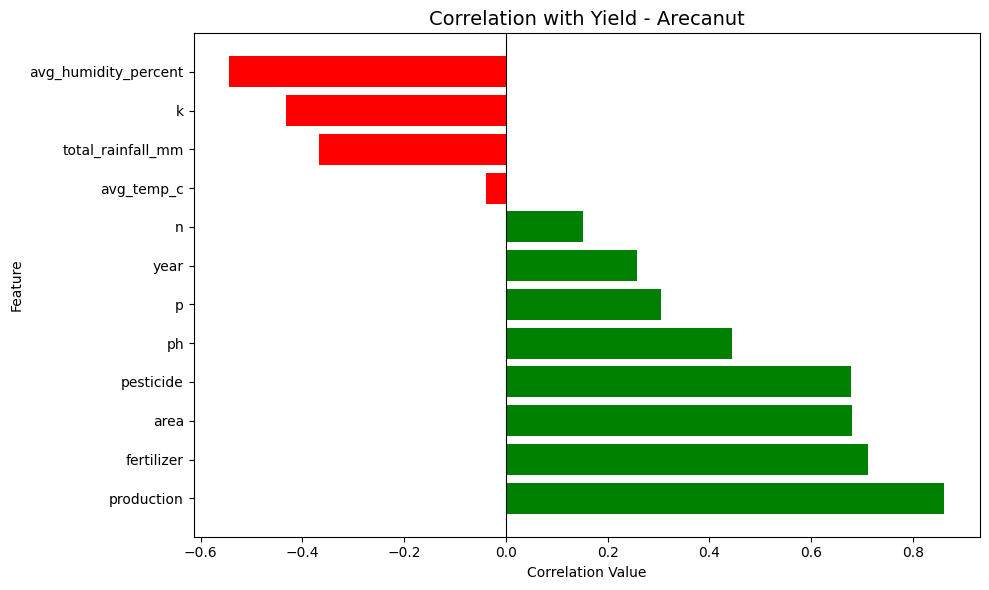

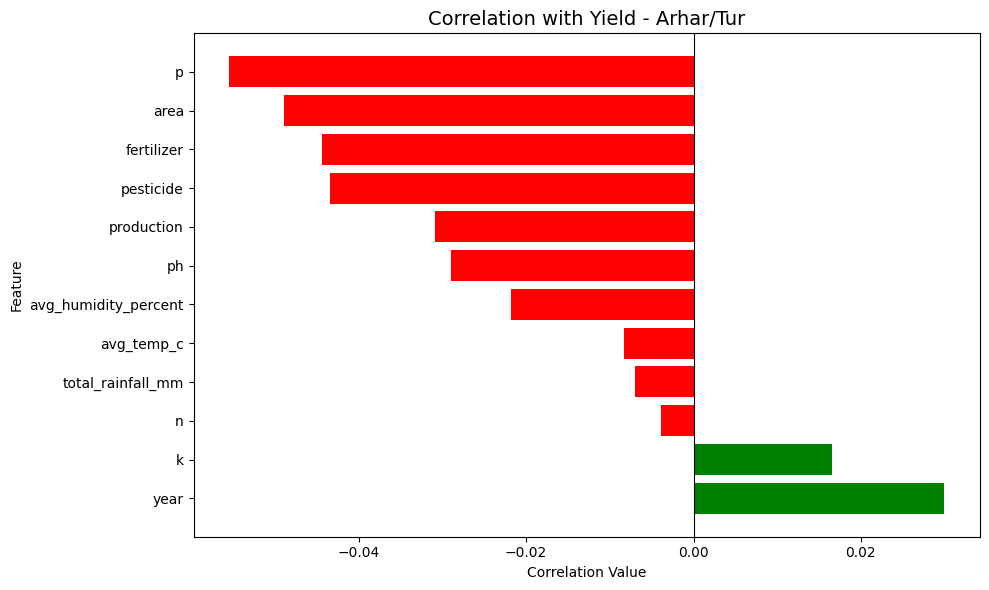

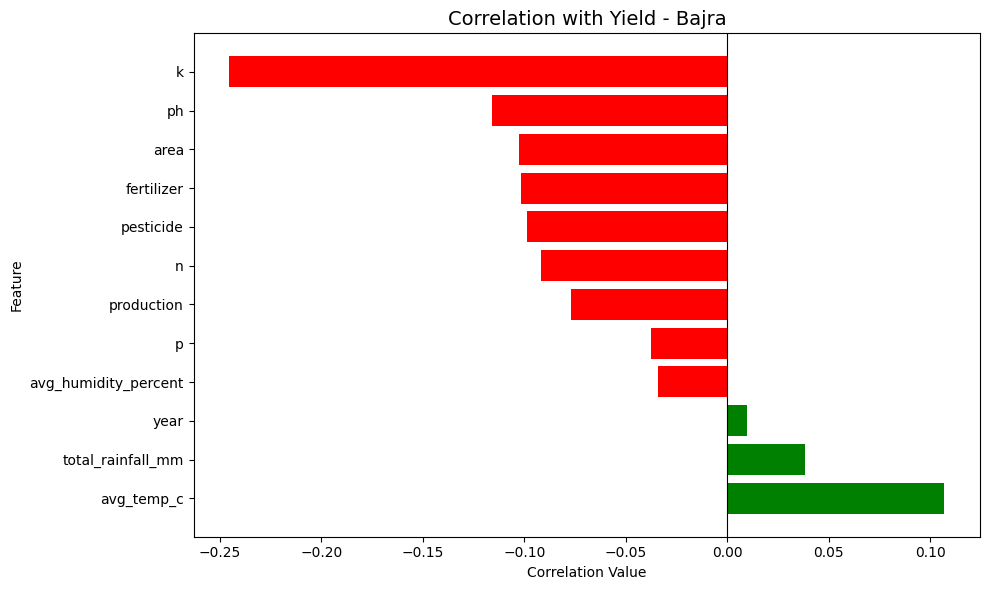

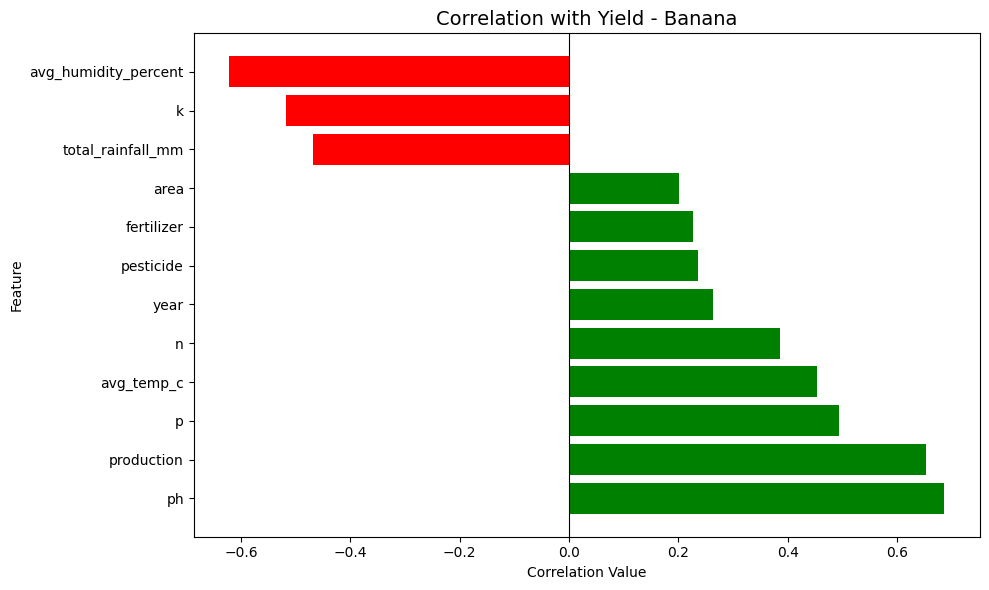

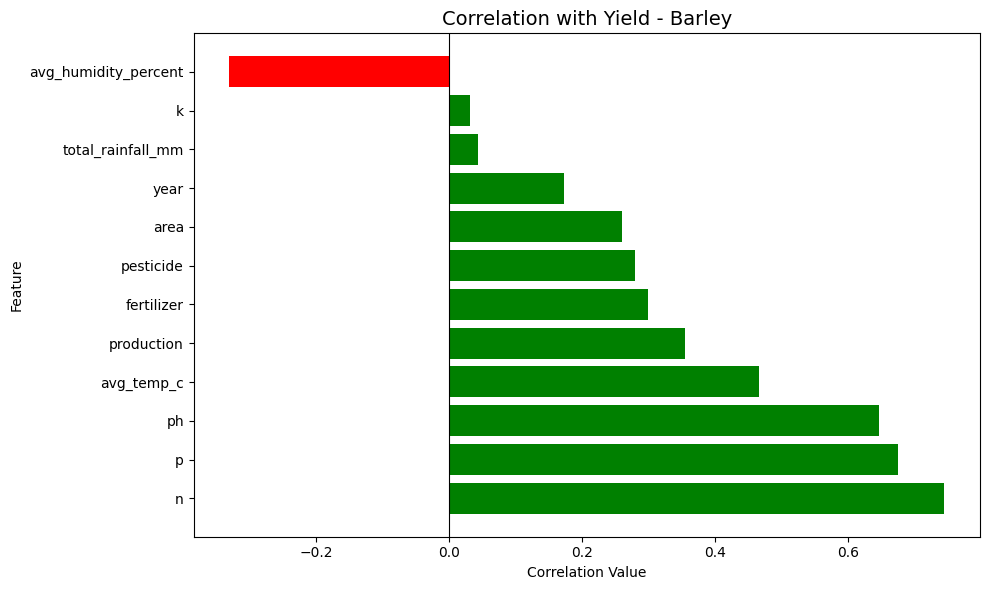

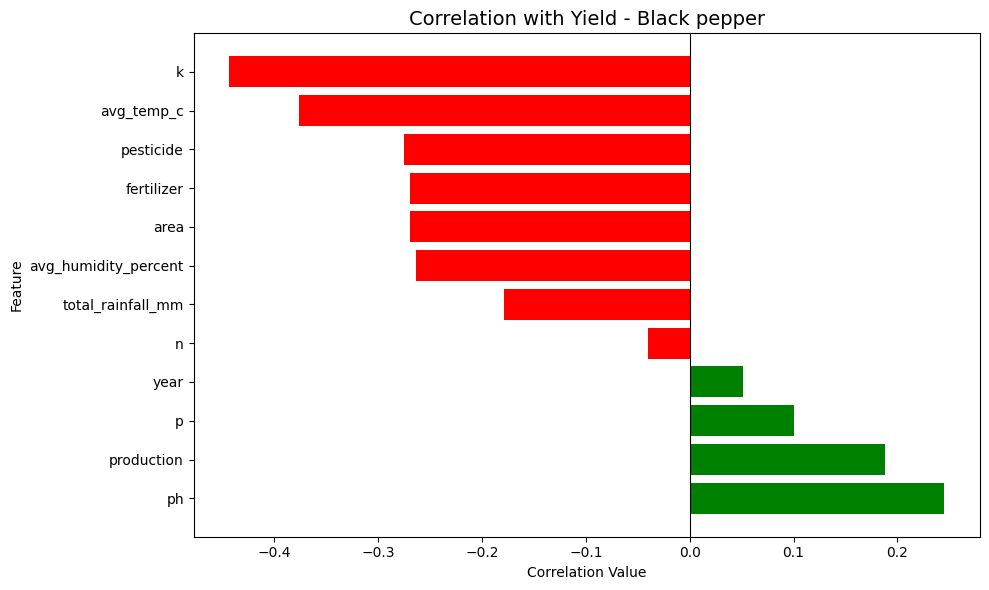

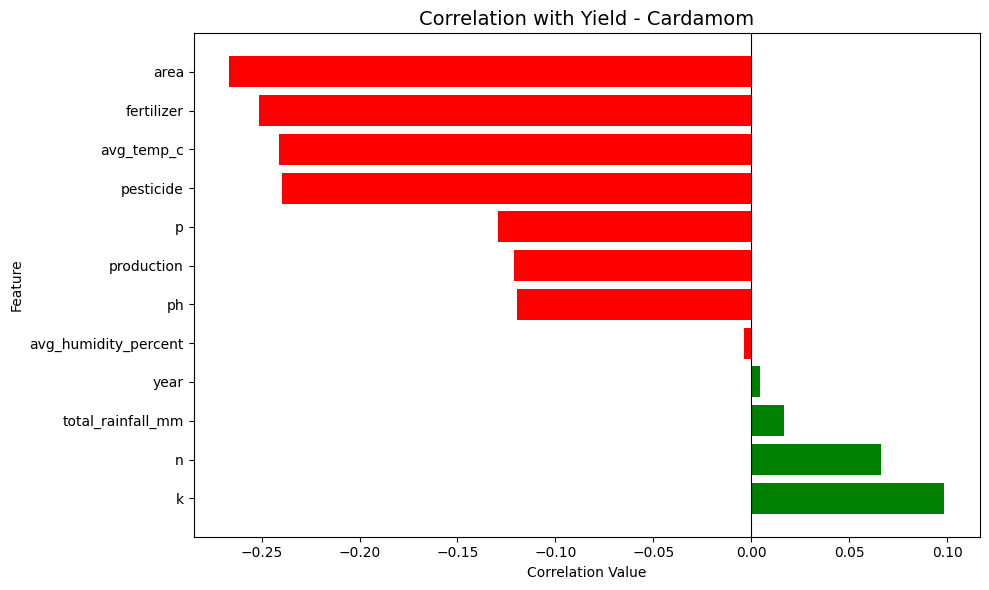

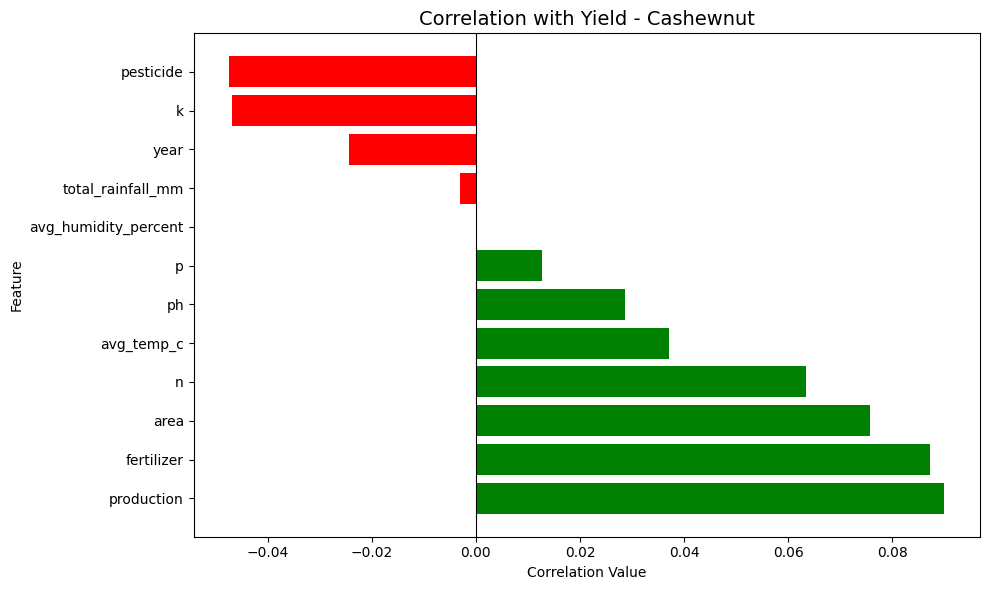

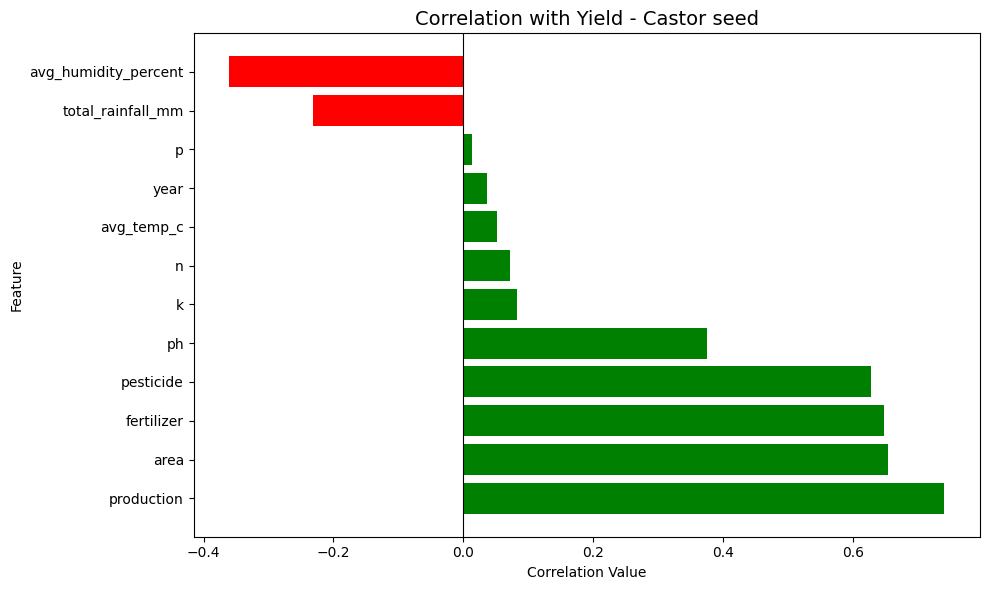

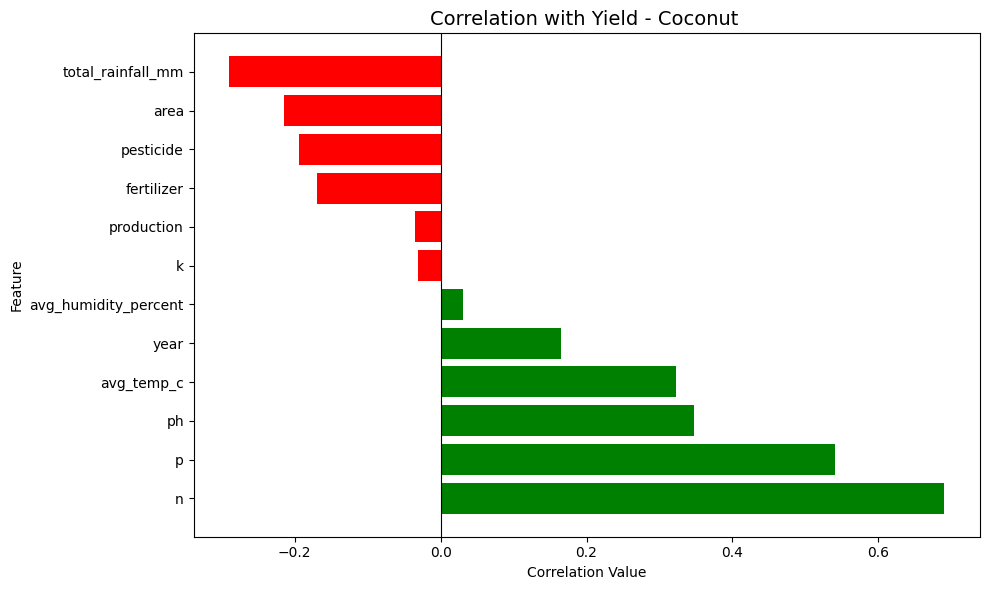

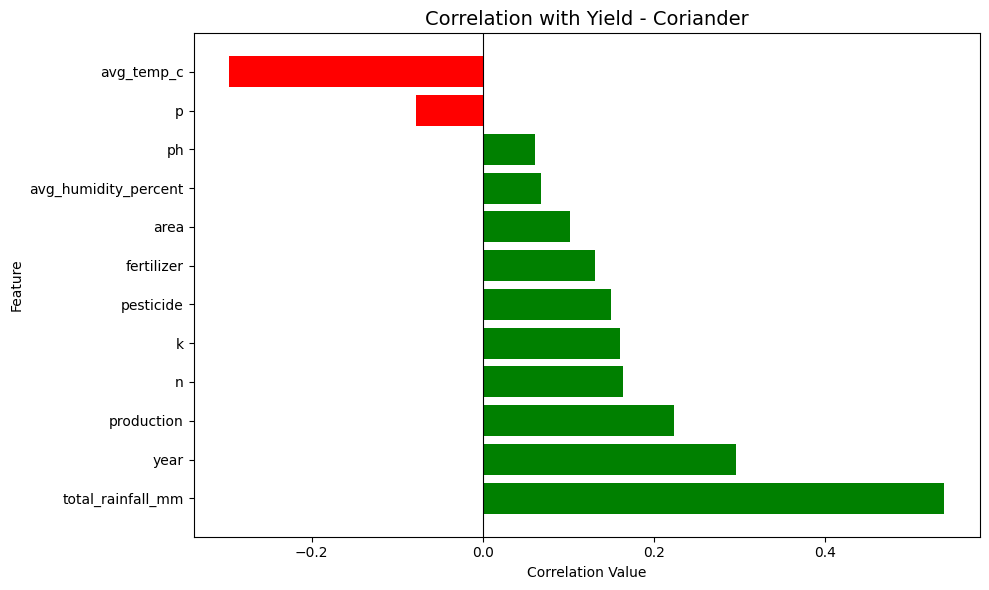

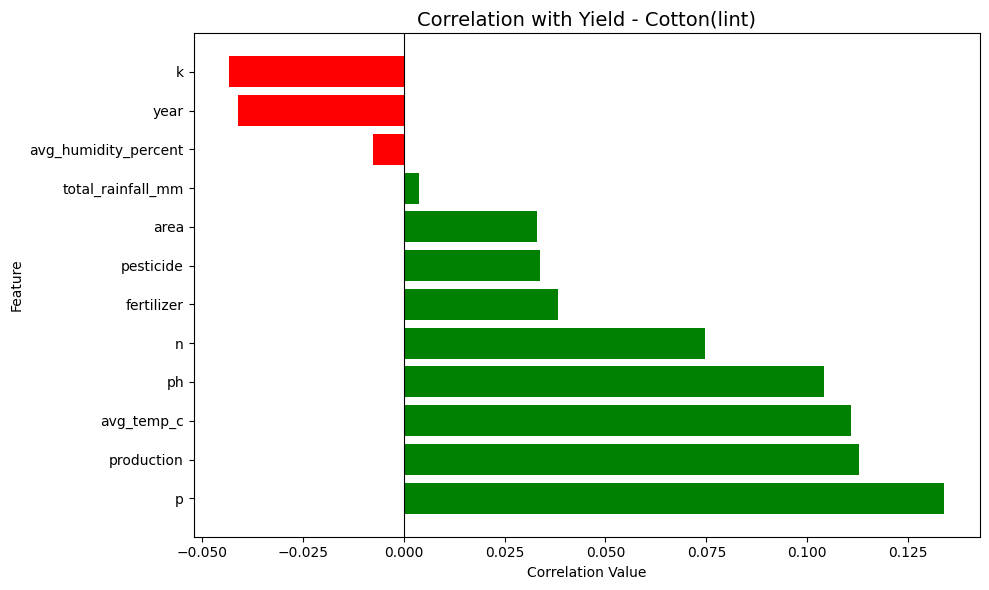

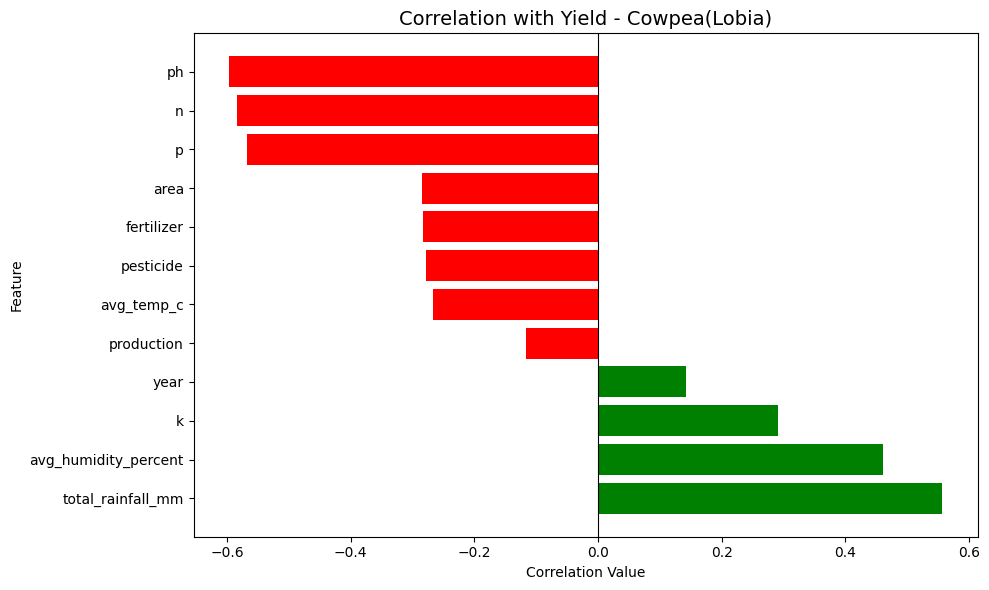

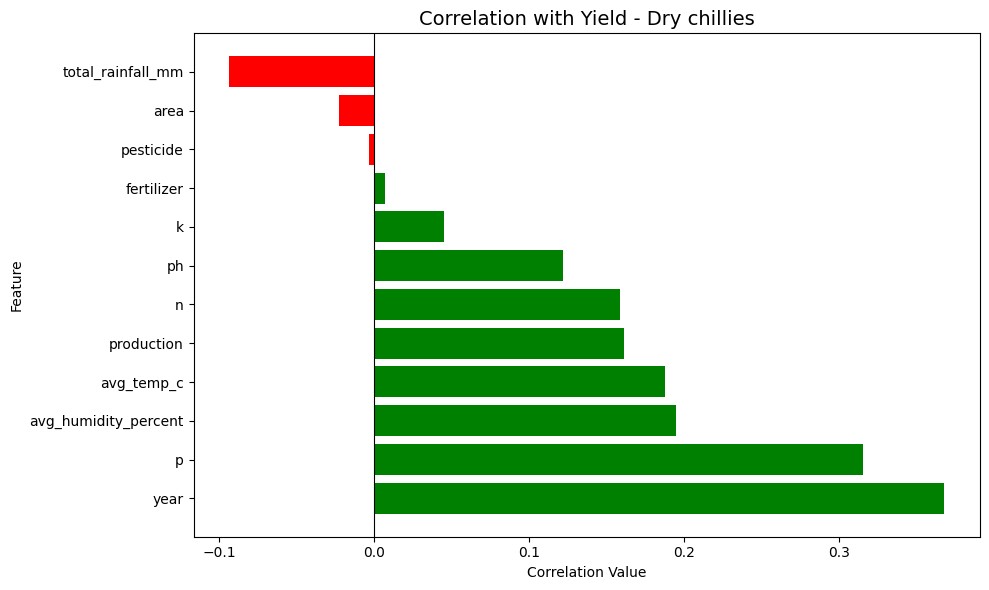

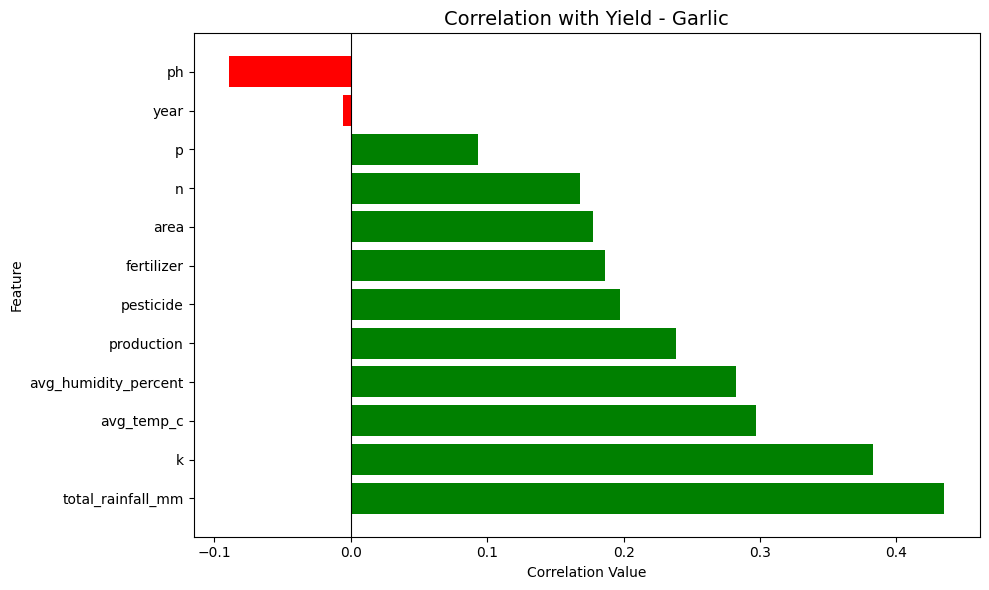

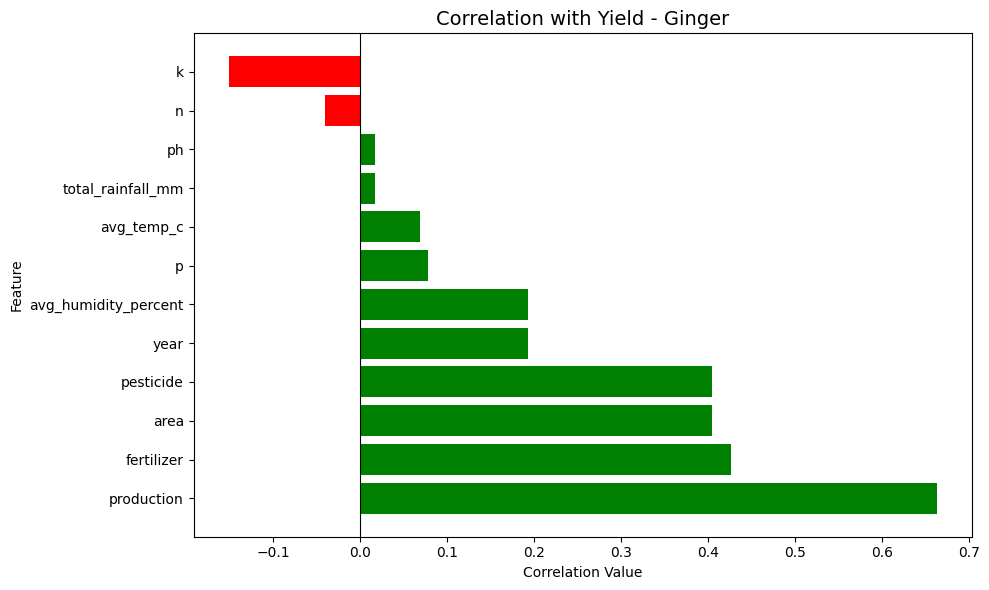

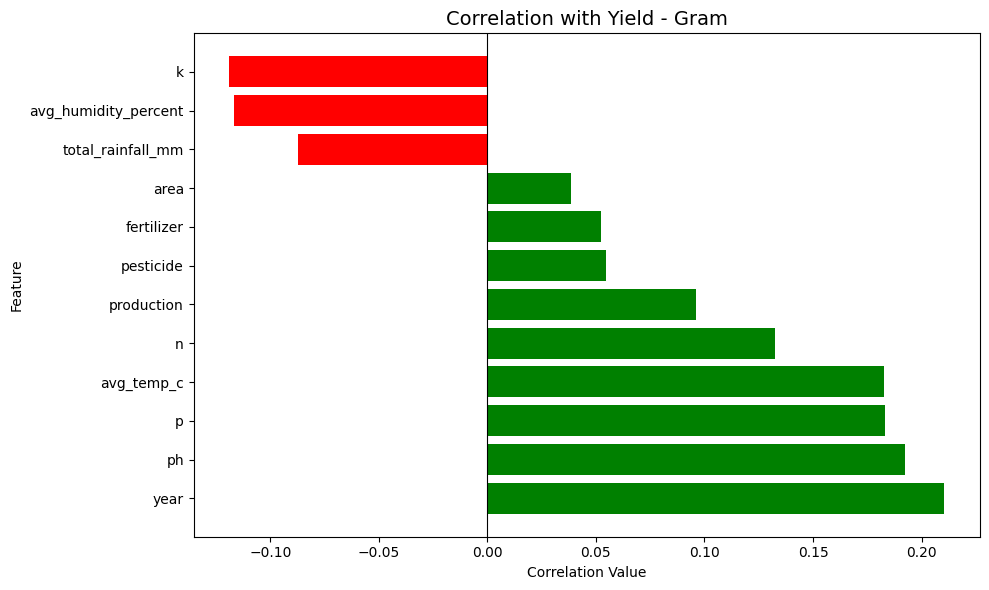

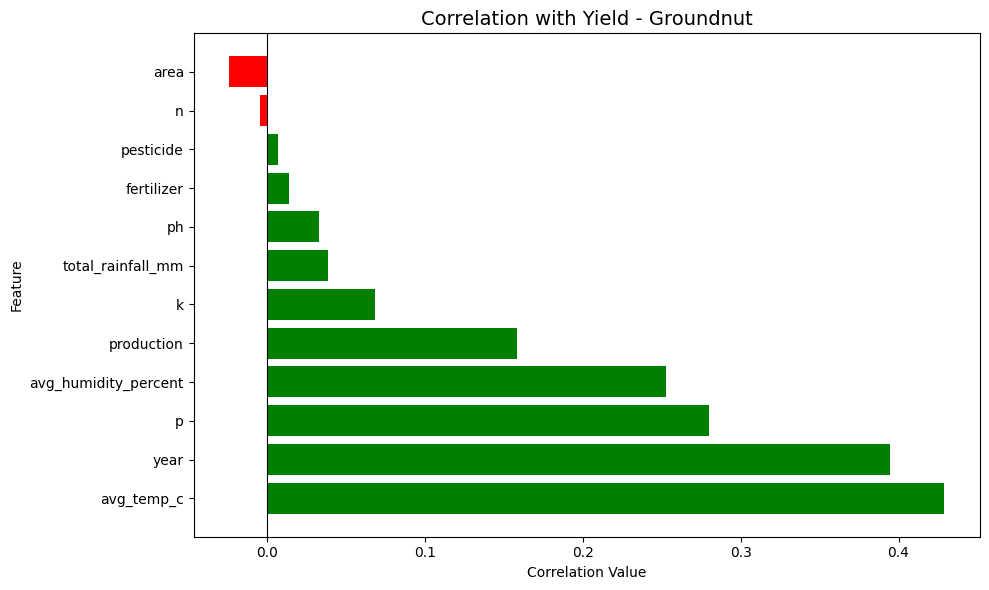

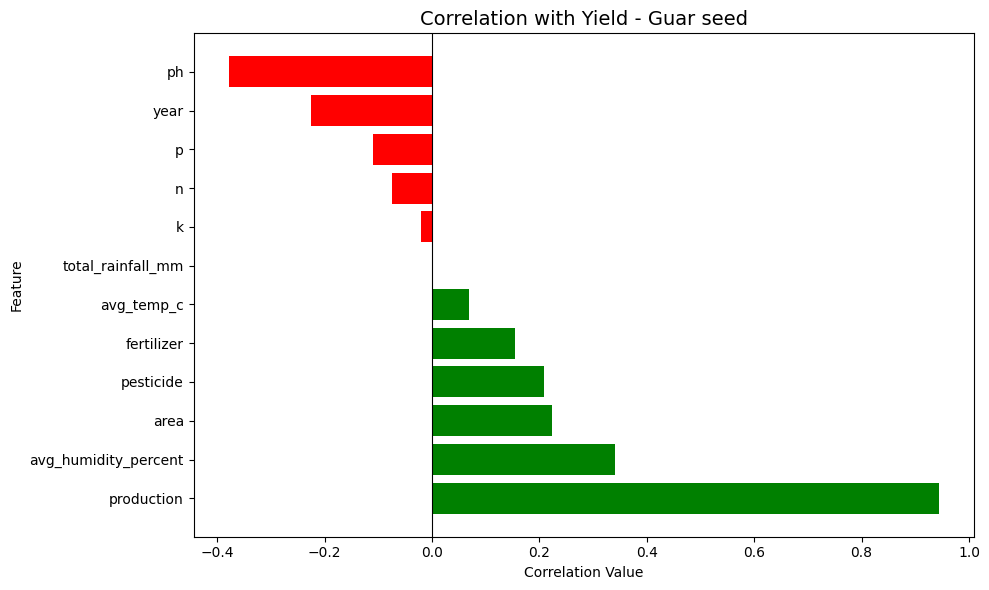

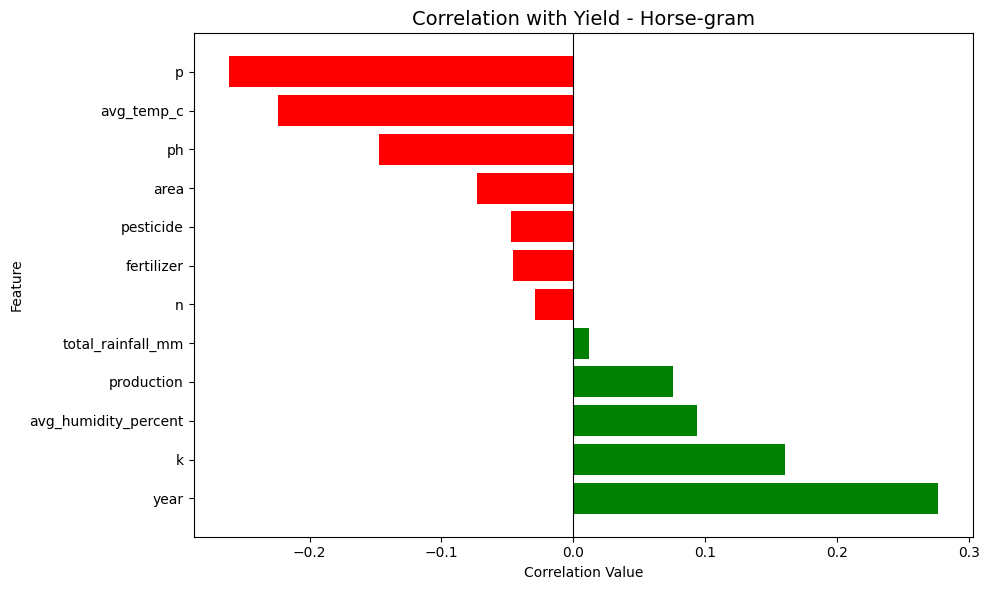

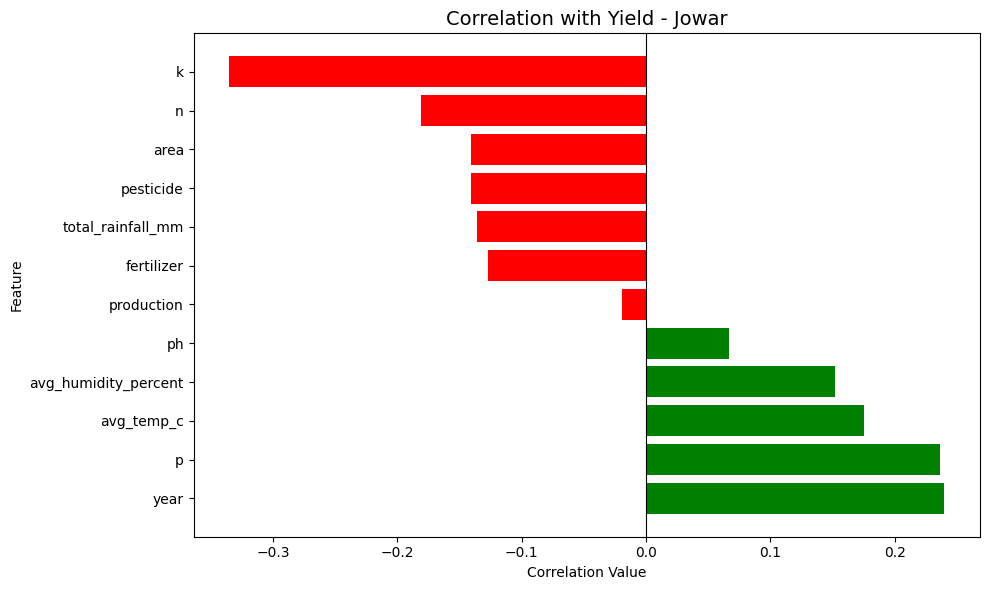

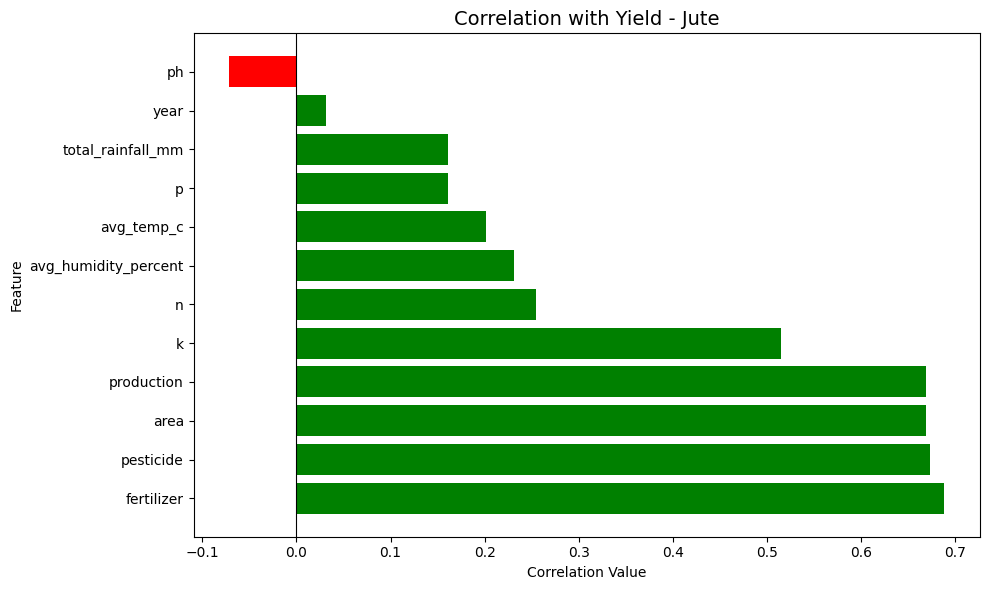

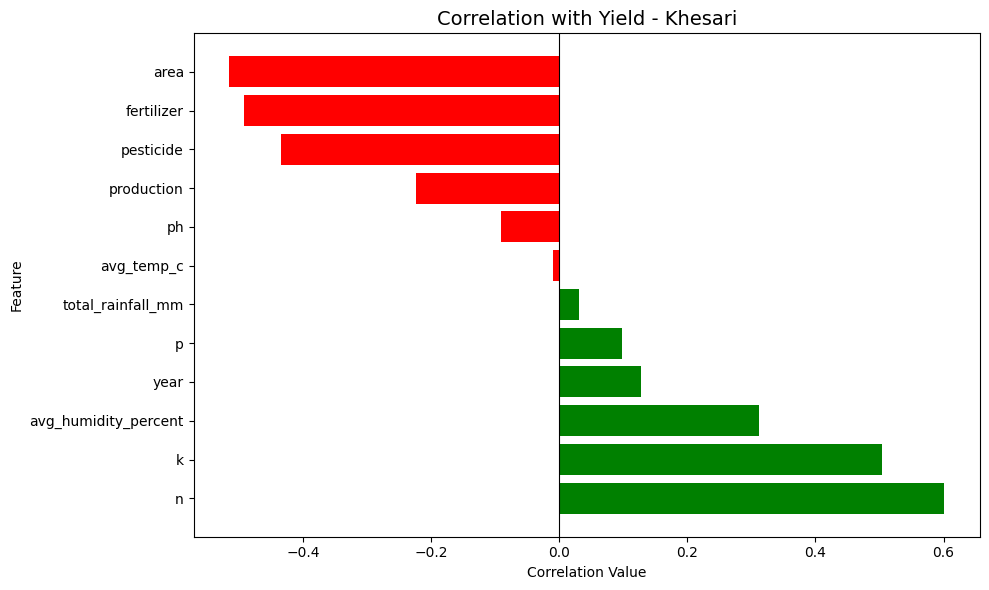

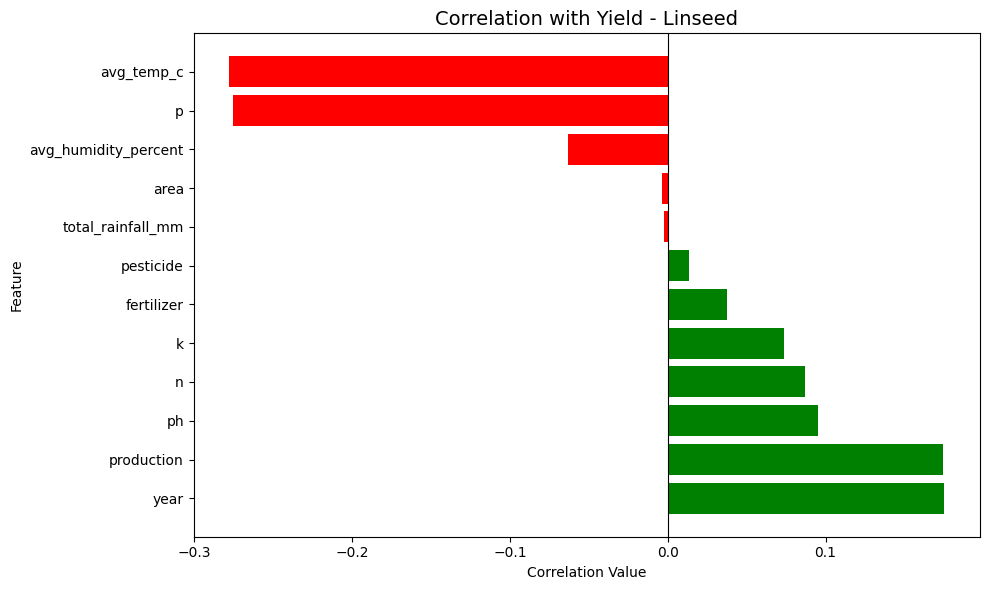

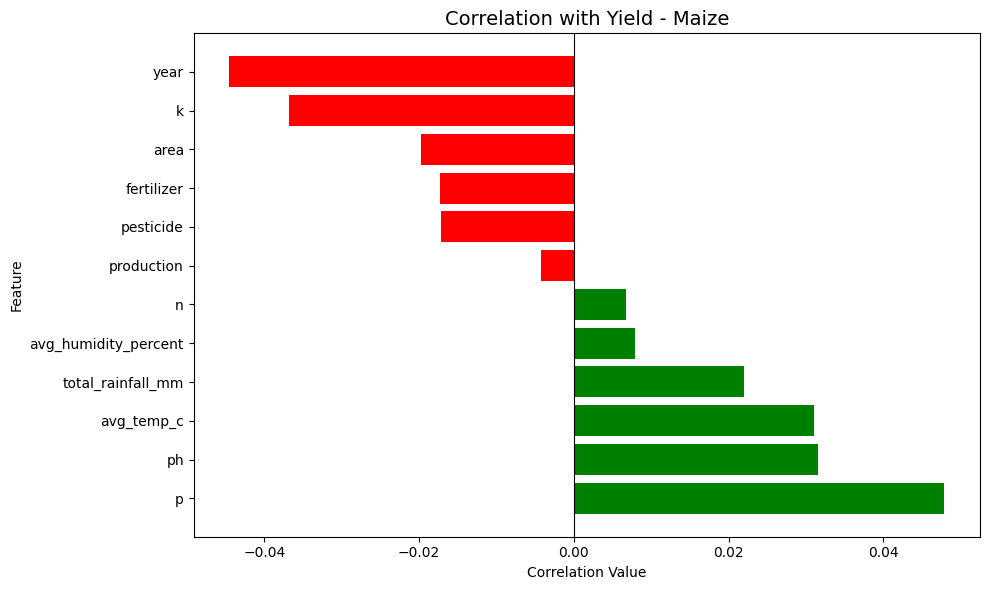

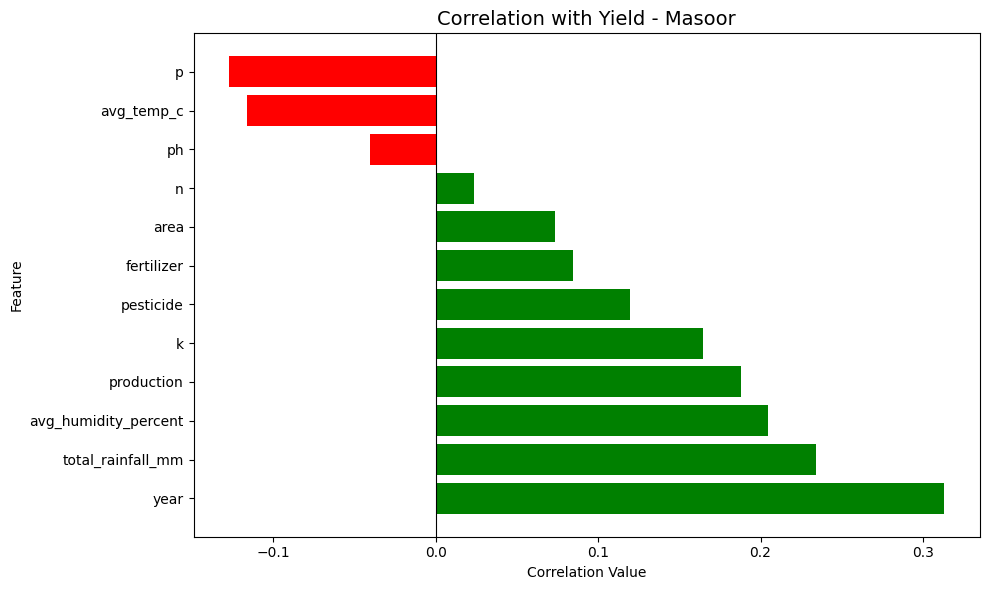

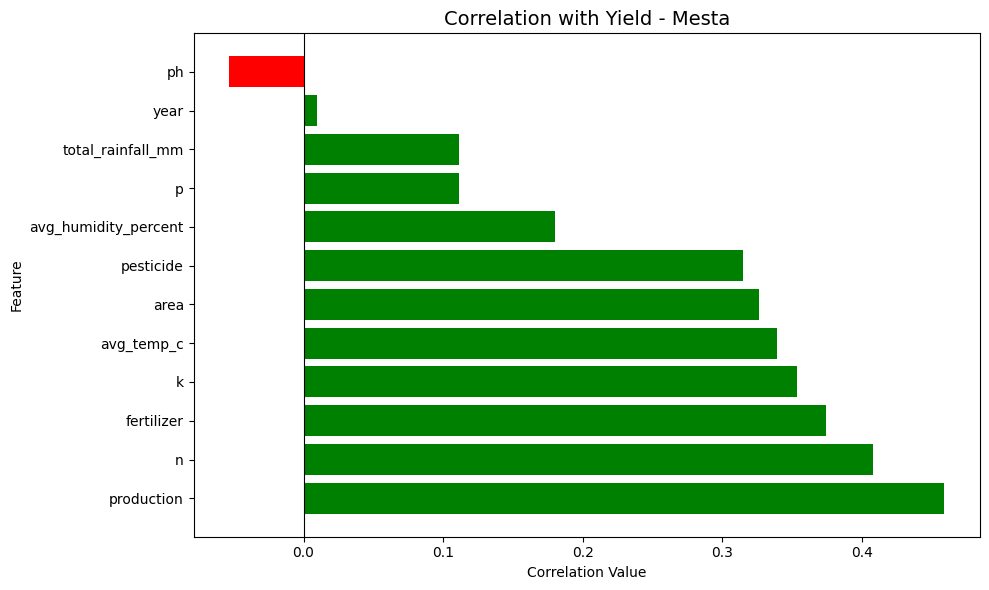

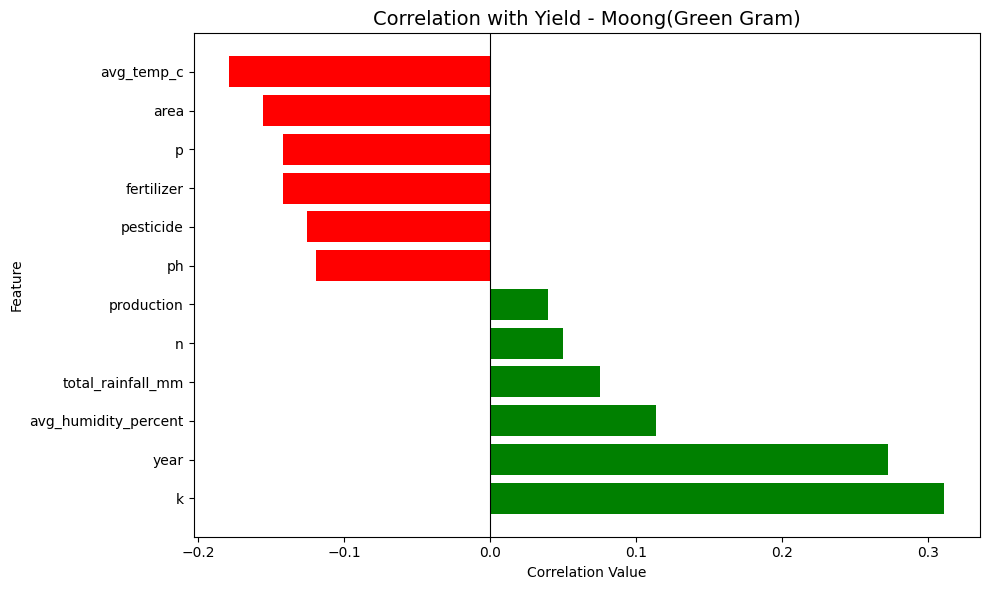

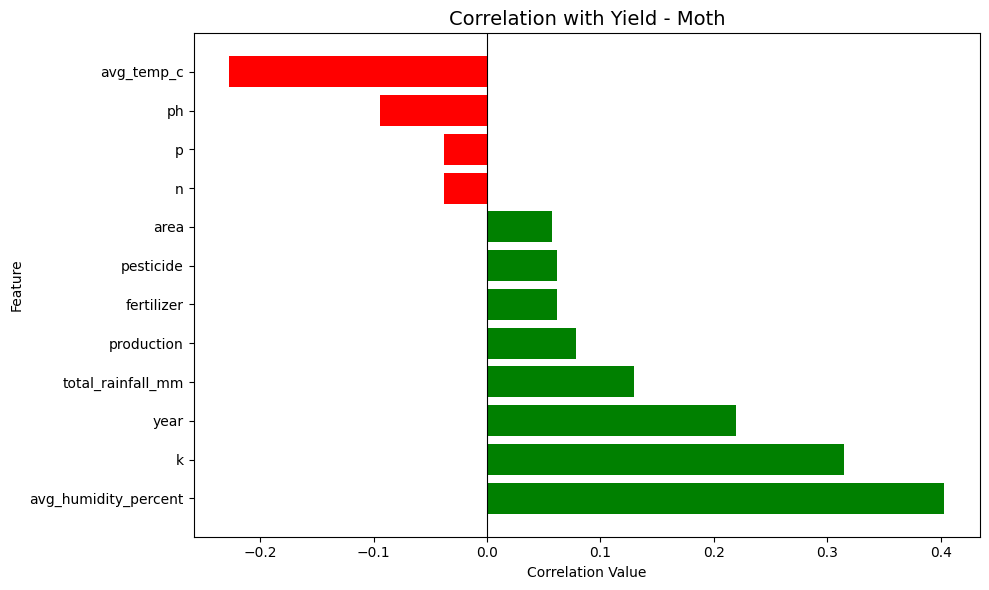

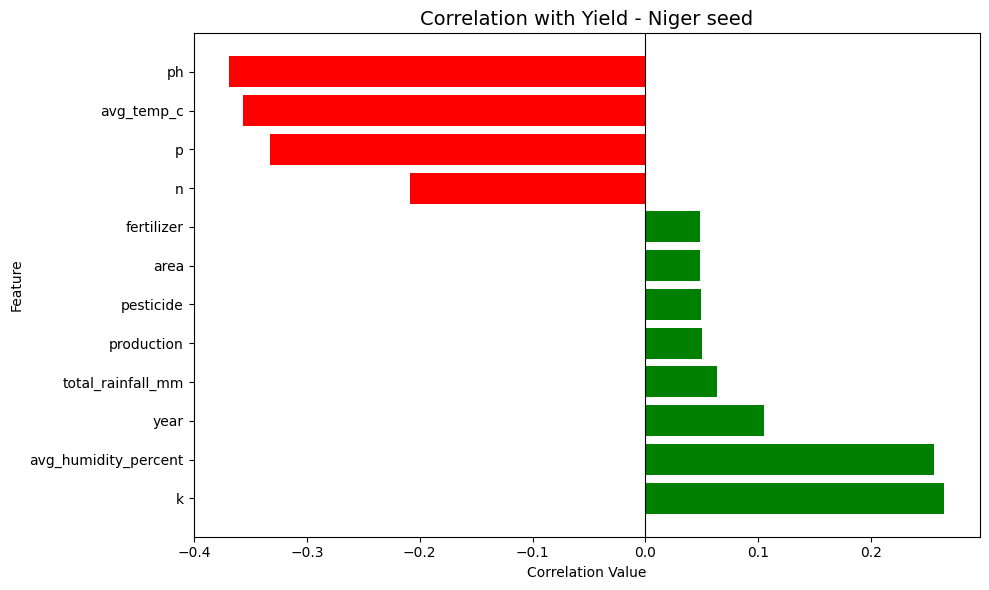

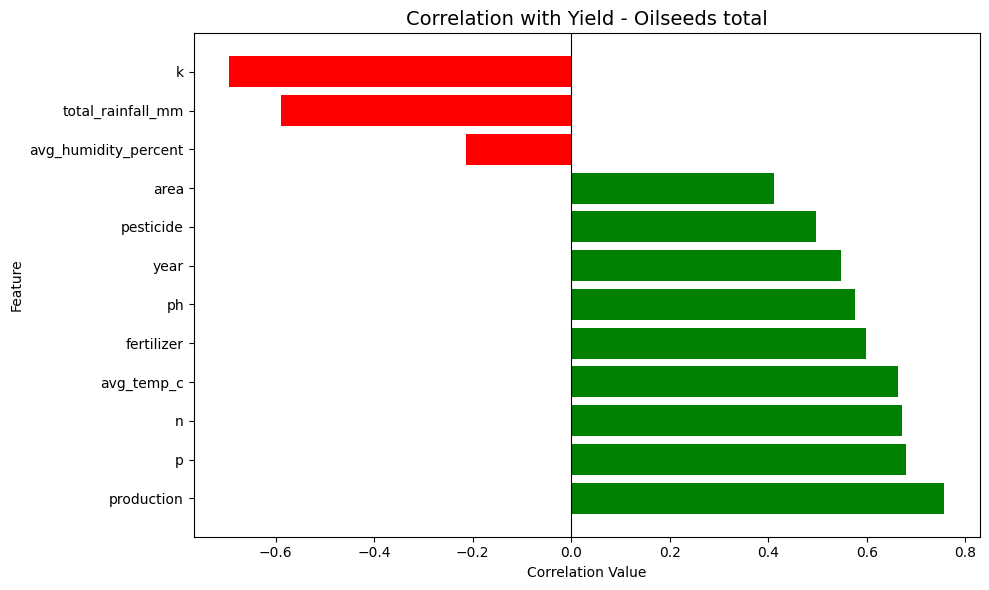

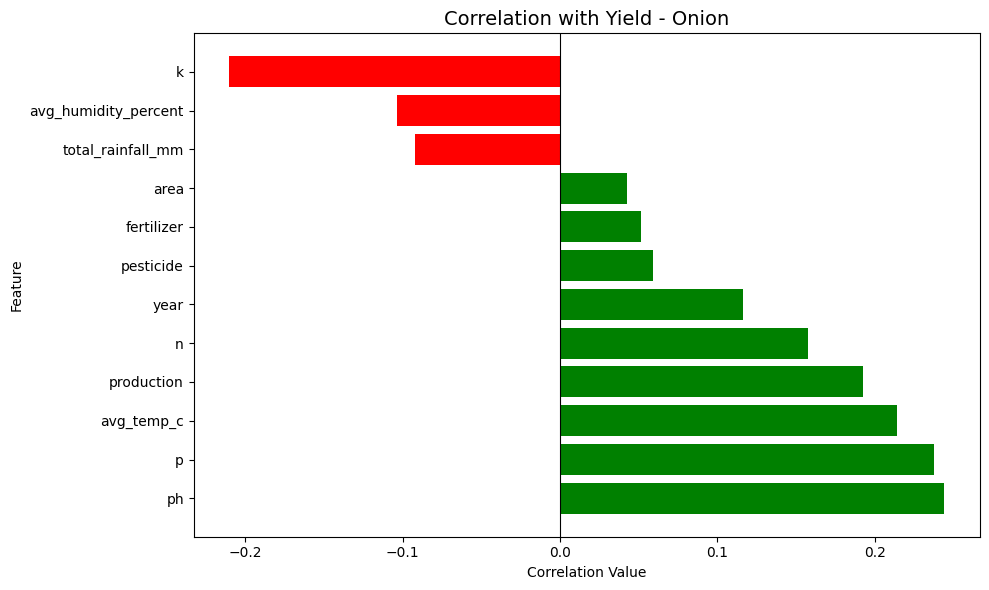

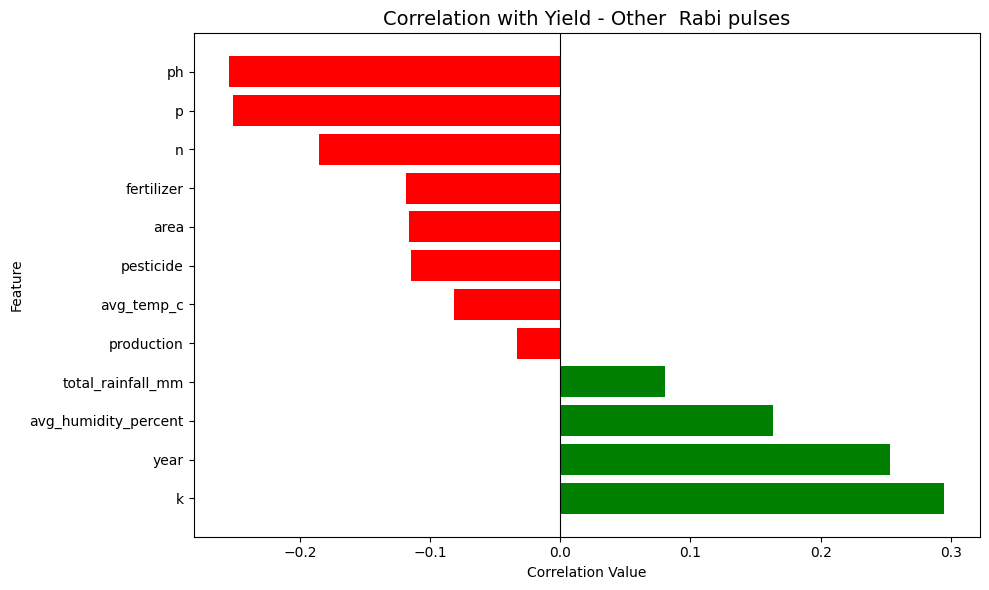

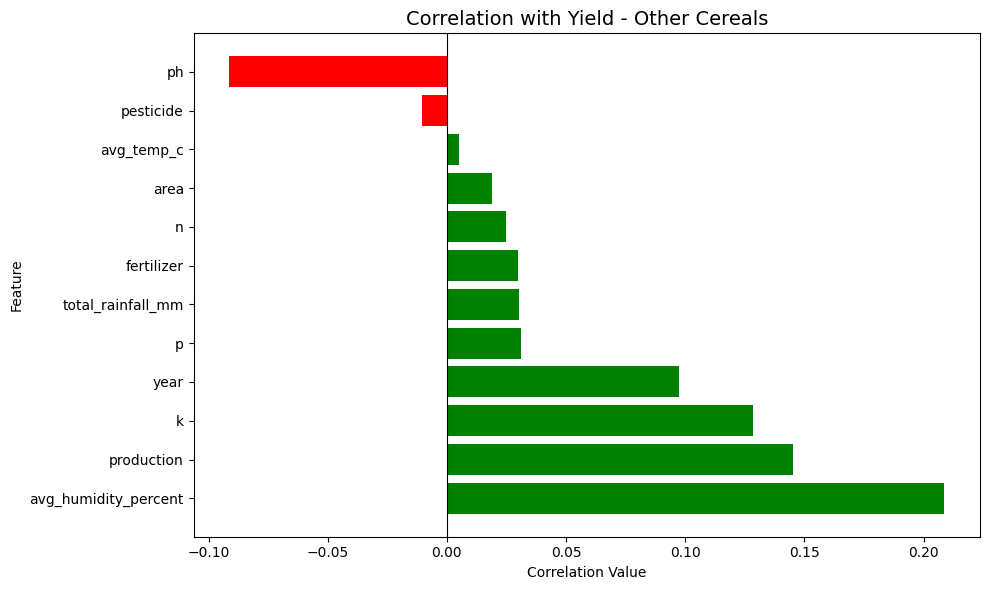

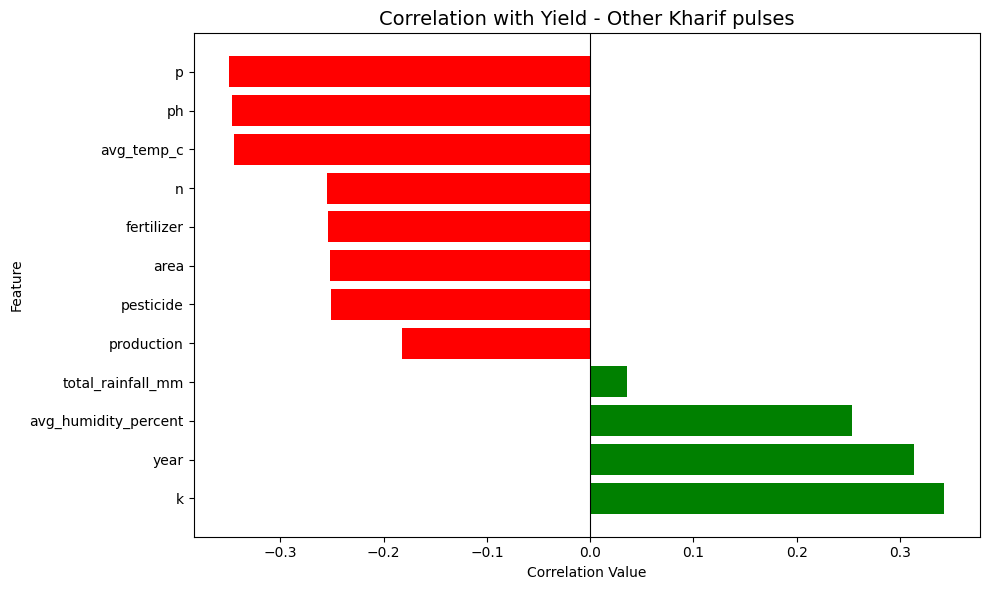

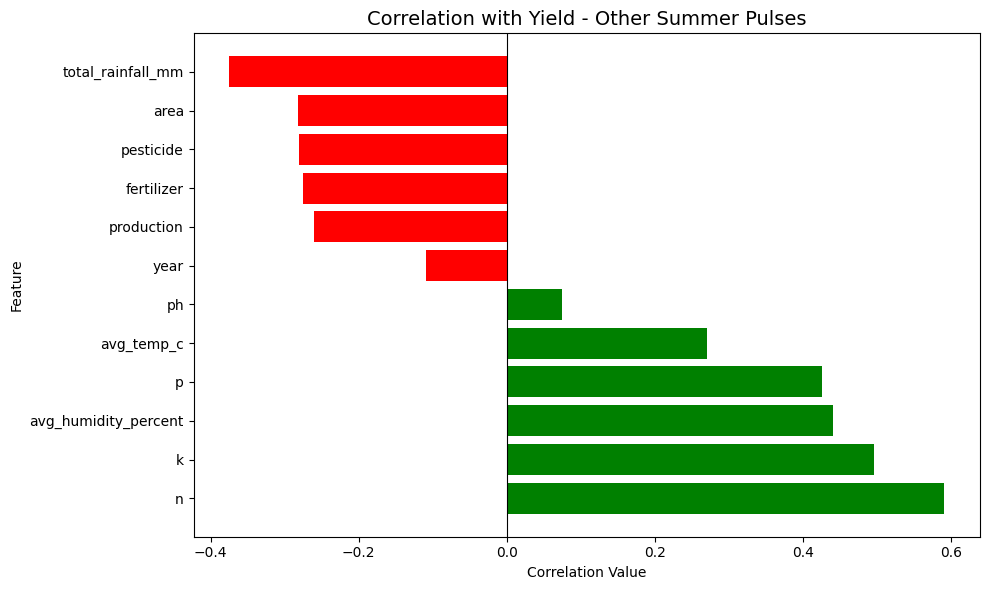

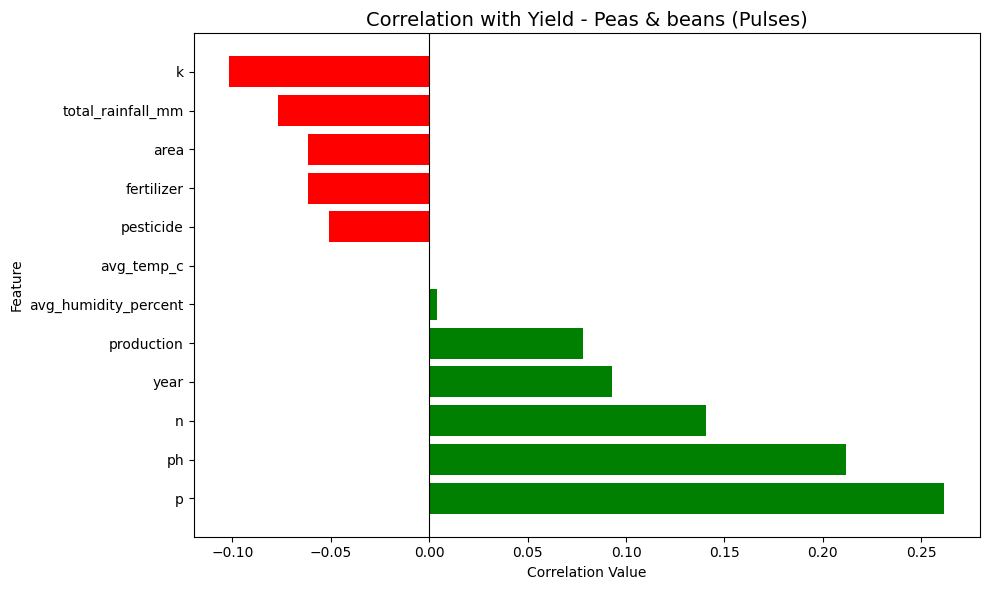

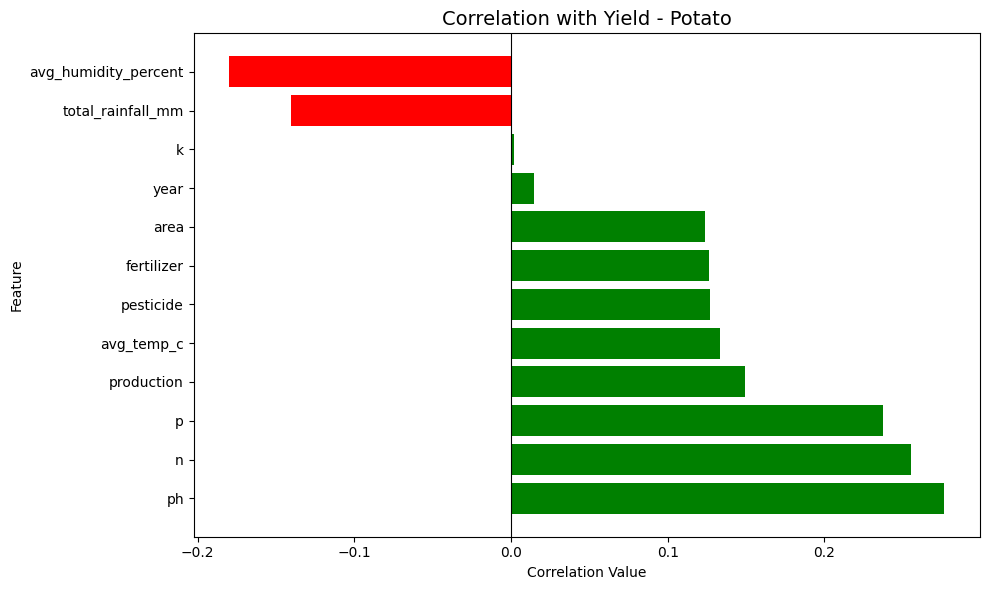

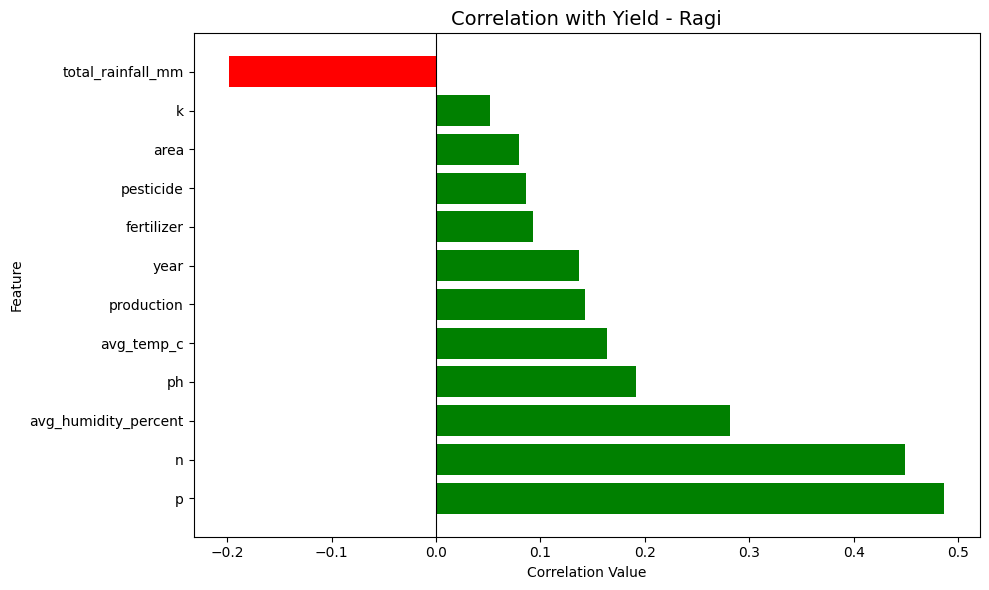

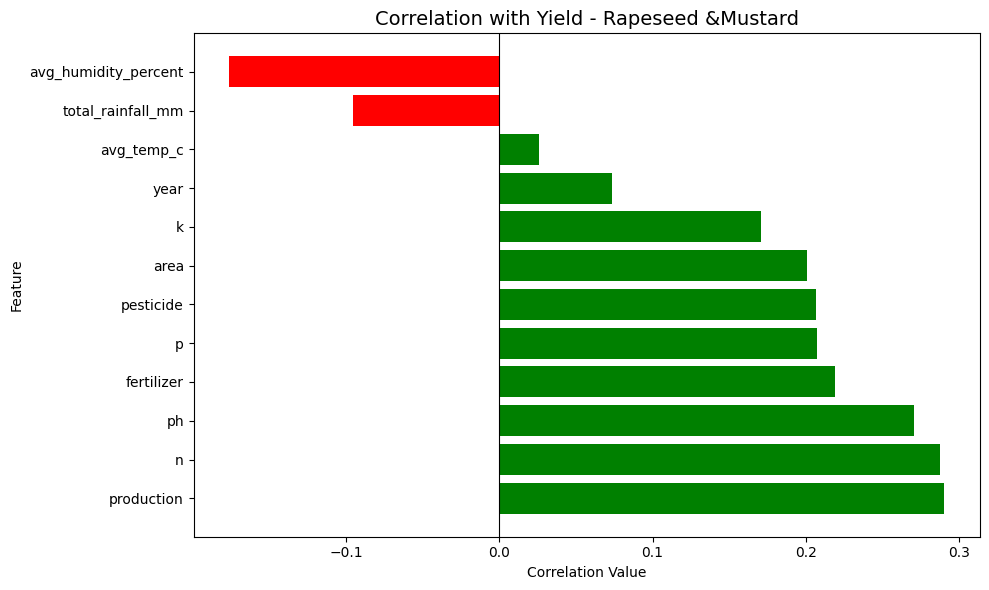

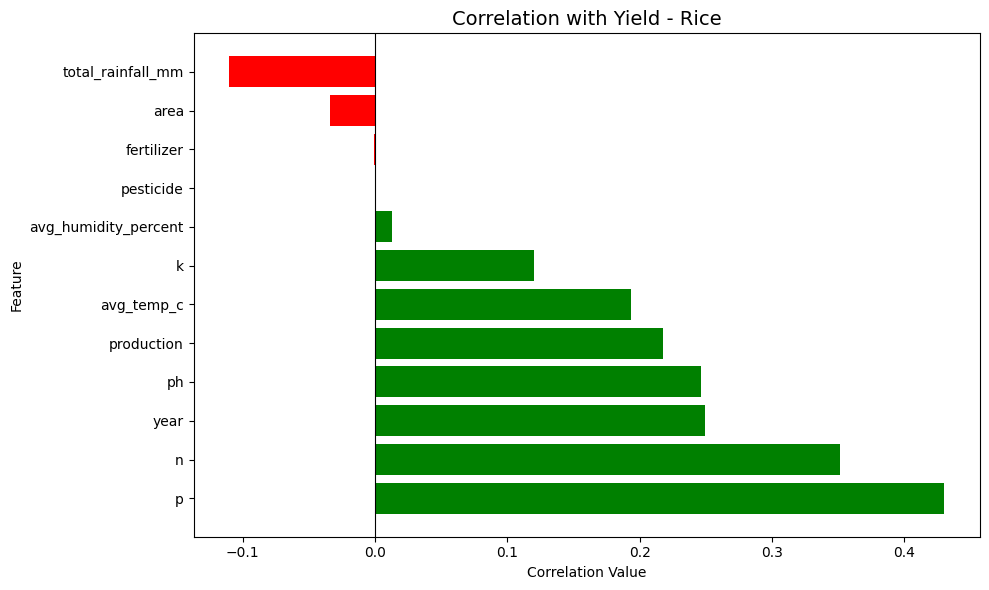

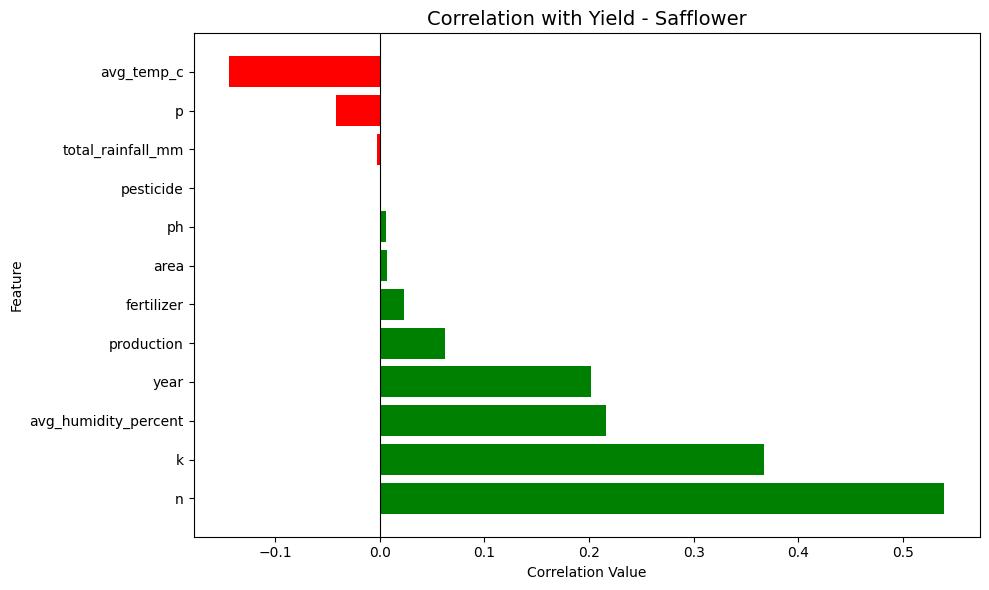

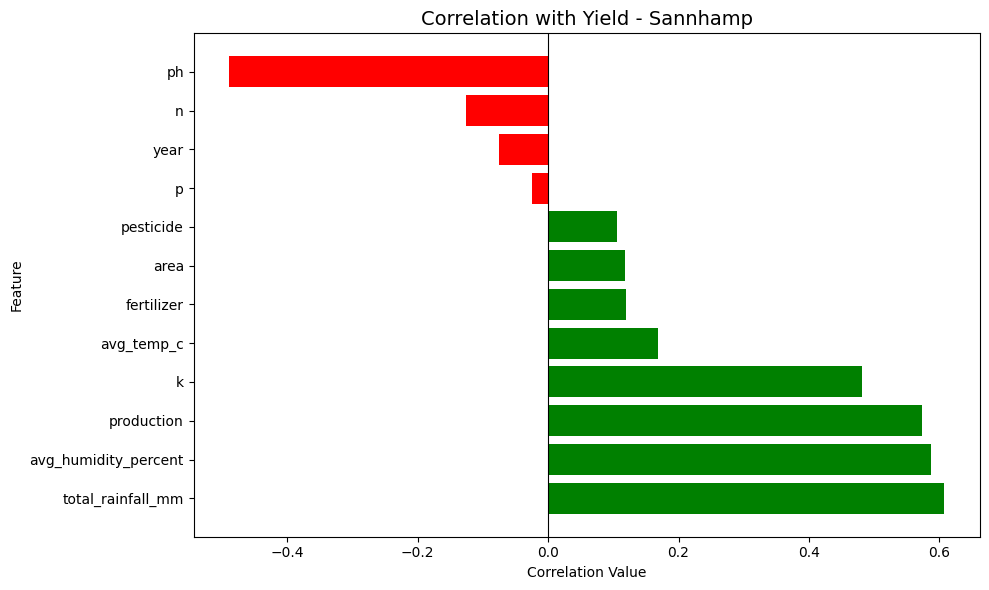

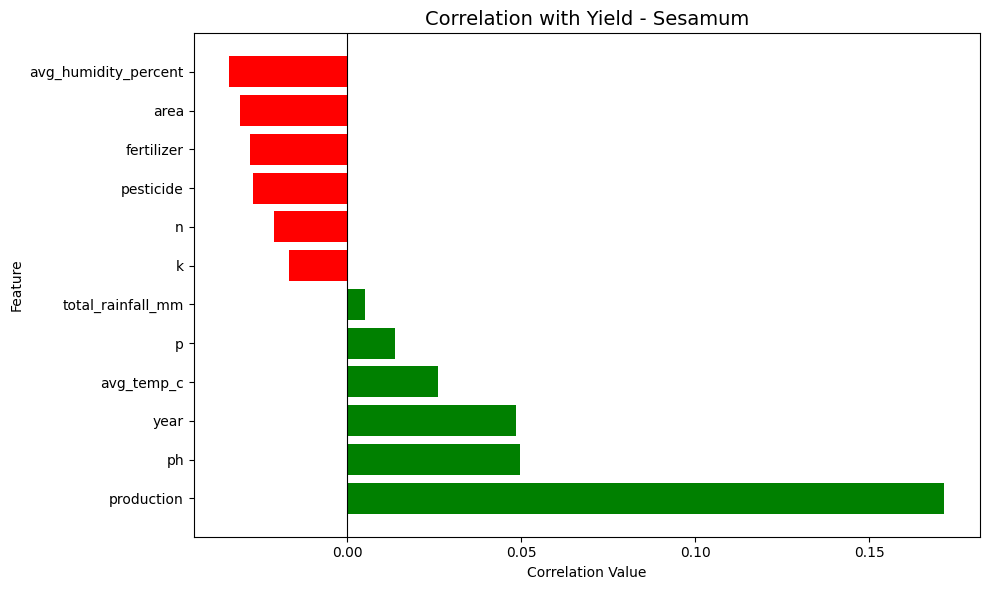

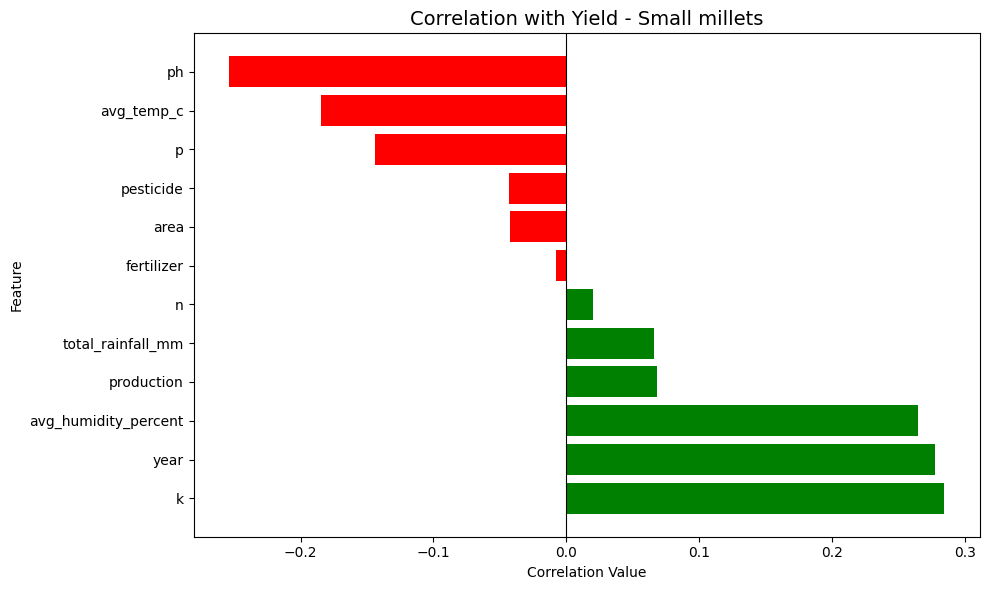

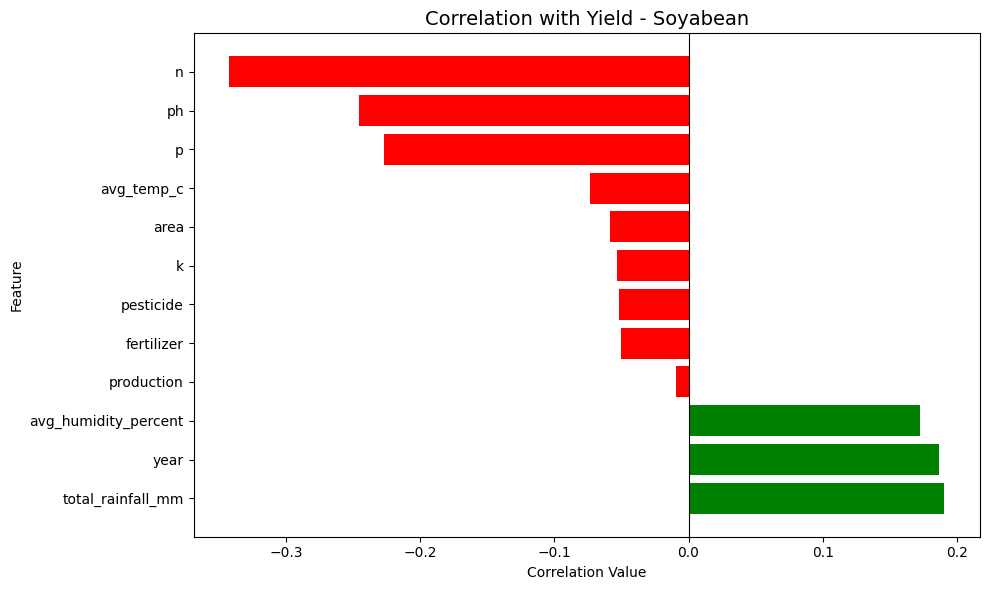

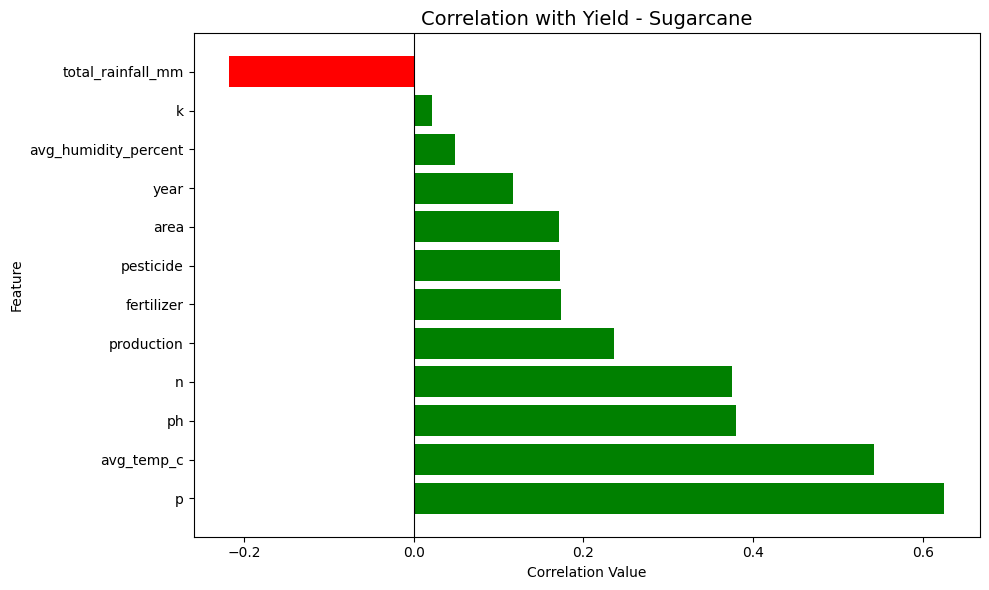

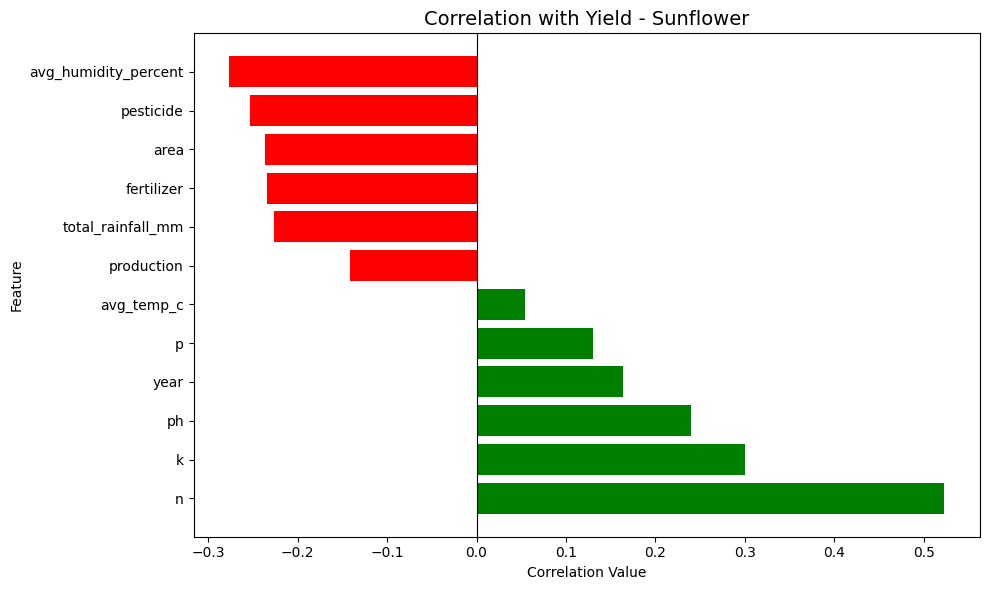

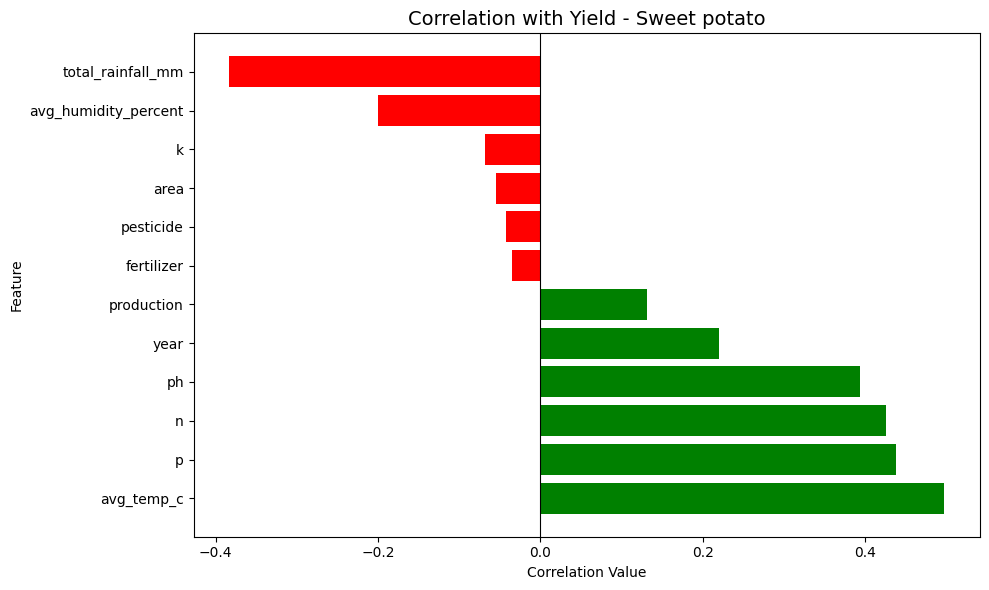

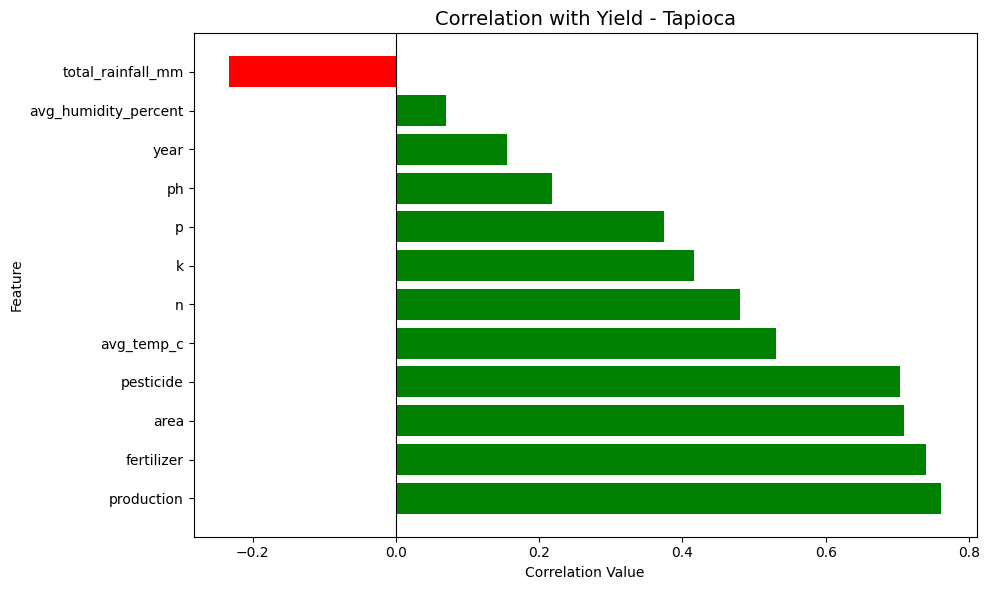

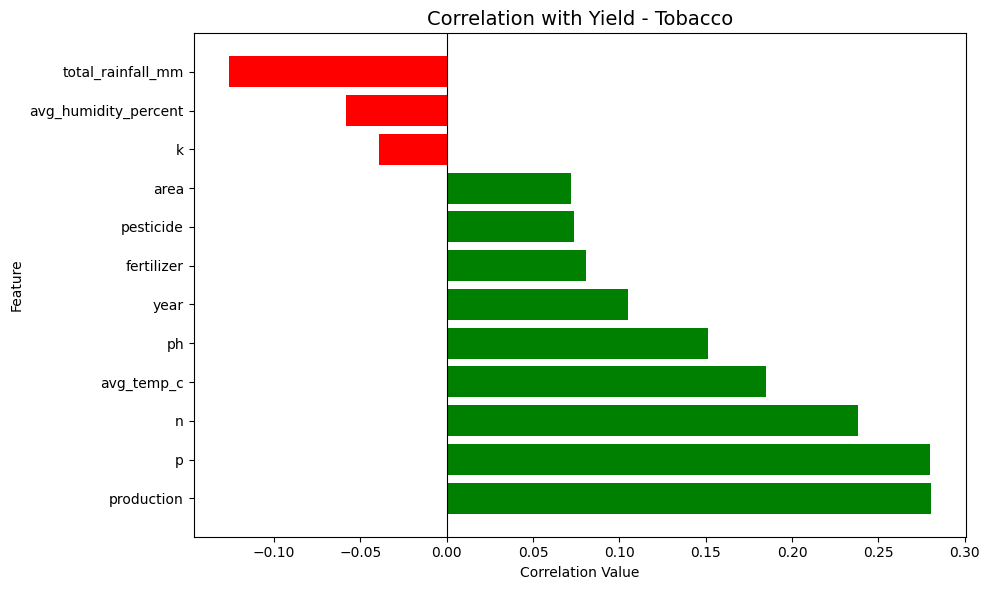

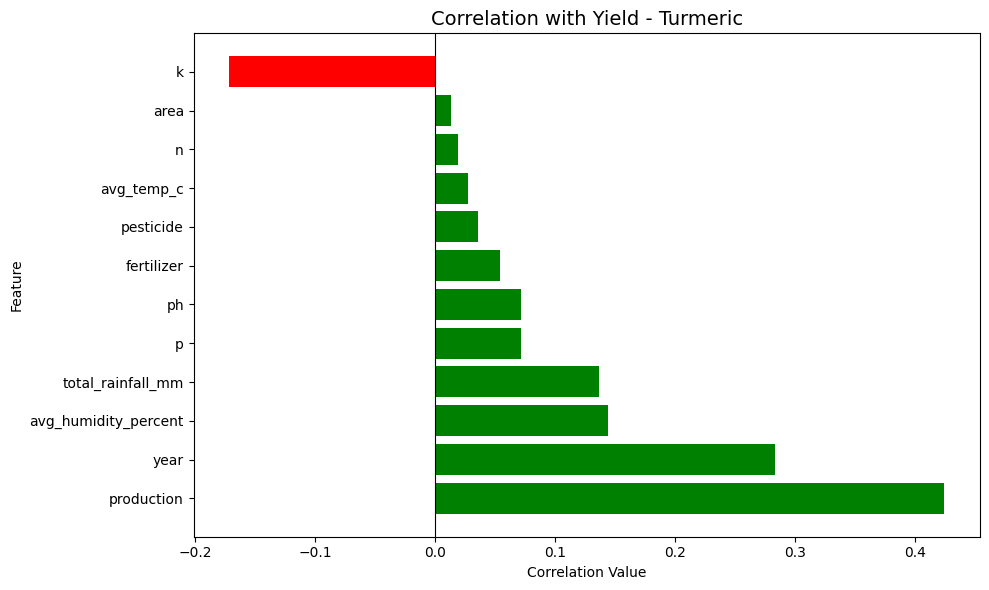

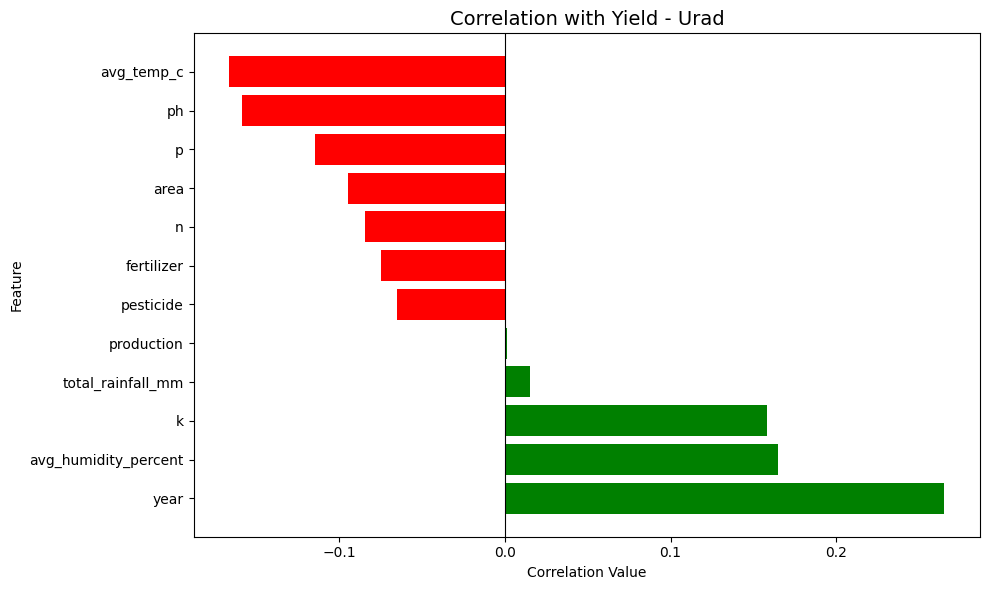

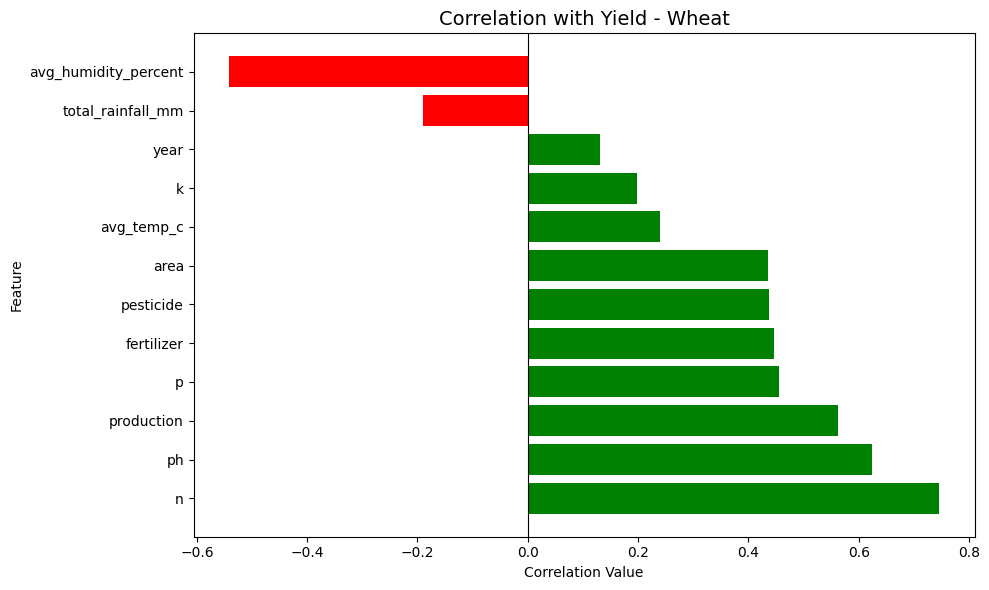

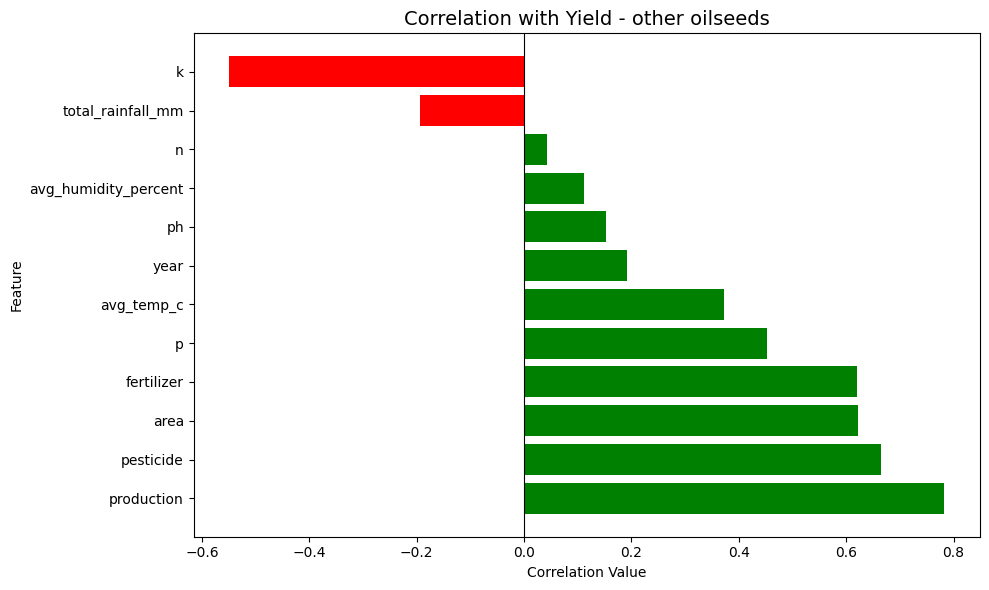

In [6]:
import pandas as pd, os

# Load and clean
path = r"C:\Users\Sania\Downloads\archive"
yield_df = pd.read_csv(os.path.join(path, "crop_yield.csv"))
soil_df = pd.read_csv(os.path.join(path, "state_soil_data.csv"))
weather_df = pd.read_csv(os.path.join(path, "state_weather_data_1997_2020.csv"))
for df in [yield_df, soil_df, weather_df]:
    df.rename(columns=lambda x: x.strip().lower().replace(" ", "_"), inplace=True)

# Merge
merged = yield_df.merge(weather_df, on=["state","year"], how="left").merge(soil_df, on="state", how="left")

# Farmer-friendly advice
print("\n🚜 Farmer-Friendly Advice:\n")
for crop, group in merged.groupby("crop"):
    if "yield" not in group: continue
    corr = group.select_dtypes("number").corr()["yield"].drop("yield")
    print(f"\n🌱 Crop: {crop}")
    for f, v in corr.sort_values(ascending=False).items():
        print(f"   {'➕' if v>0 else '➖' if v<0 else '➖➕'} {f} {'helps' if v>0 else 'reduces' if v<0 else 'little effect'} yield")
import matplotlib.pyplot as plt

# Visualization
print("\n📊 Visualizing Correlations:\n")
for crop, group in merged.groupby("crop"):
    if "yield" not in group: 
        continue
    
    # Compute correlations
    corr = group.select_dtypes("number").corr()["yield"].drop("yield")
    if corr.empty:
        continue
    
    # Sort correlations
    corr_sorted = corr.sort_values(ascending=False)
    
    # Color coding: green for positive, red for negative
    colors = ["green" if v > 0 else "red" for v in corr_sorted]
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
    plt.title(f"Correlation with Yield - {crop}", fontsize=14)
    plt.xlabel("Correlation Value")
    plt.ylabel("Feature")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()


📊 Visualizing Correlations:



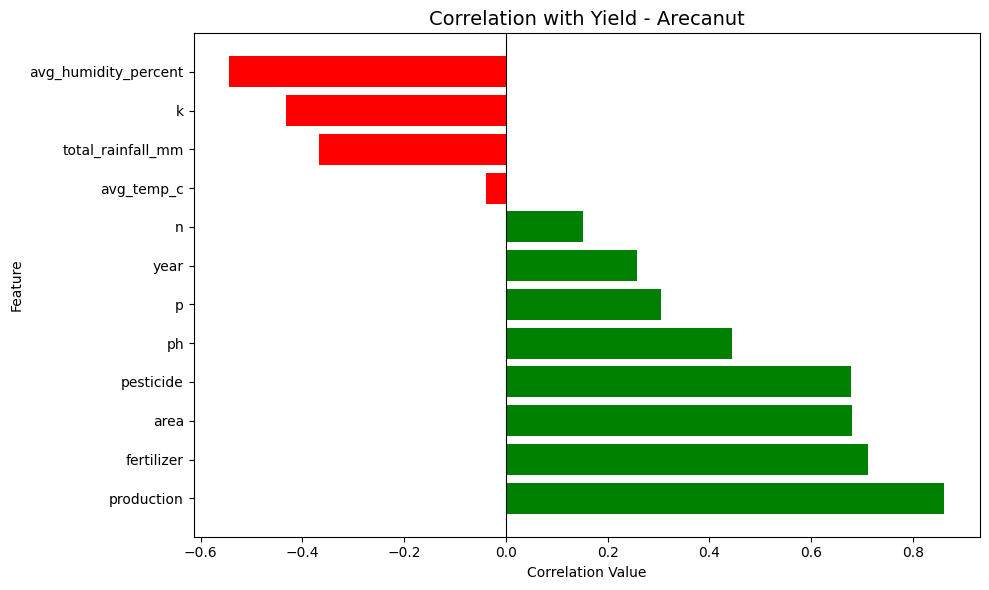

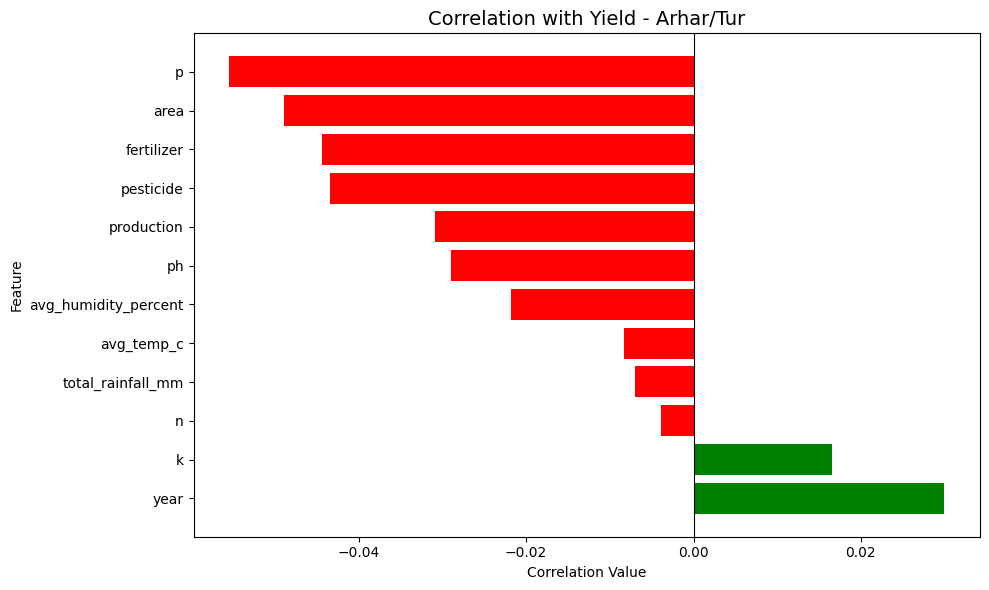

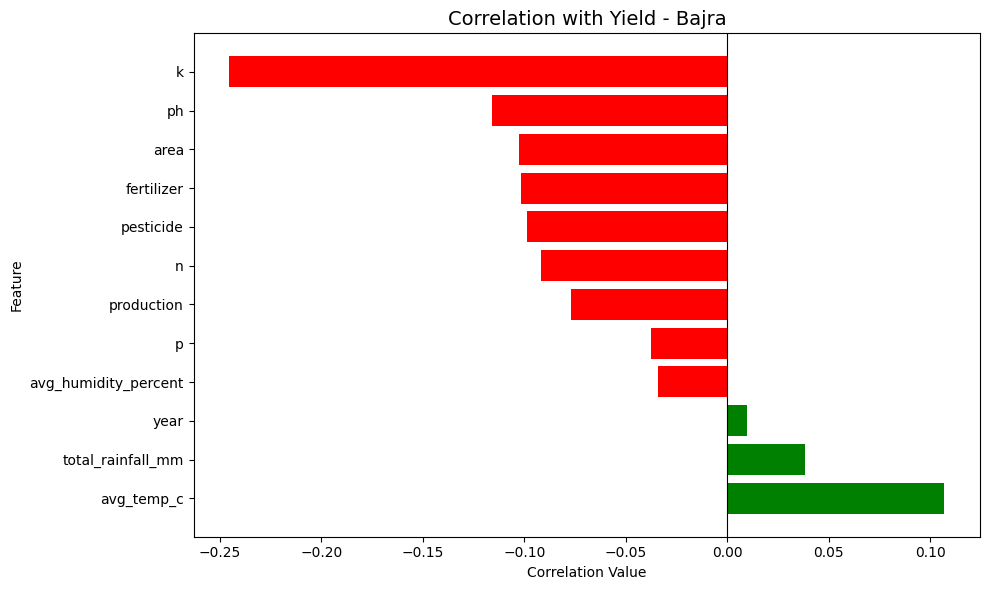

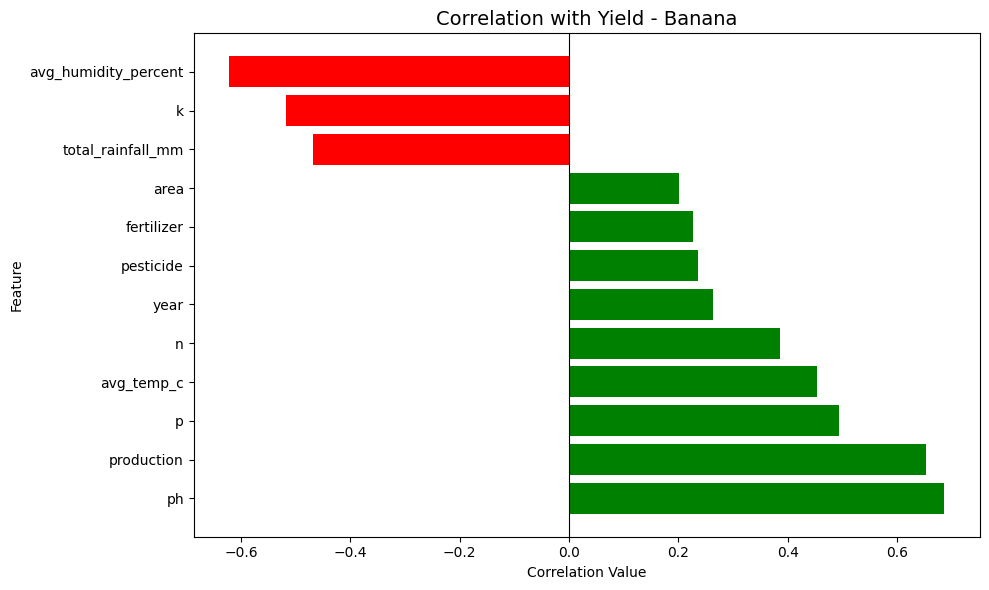

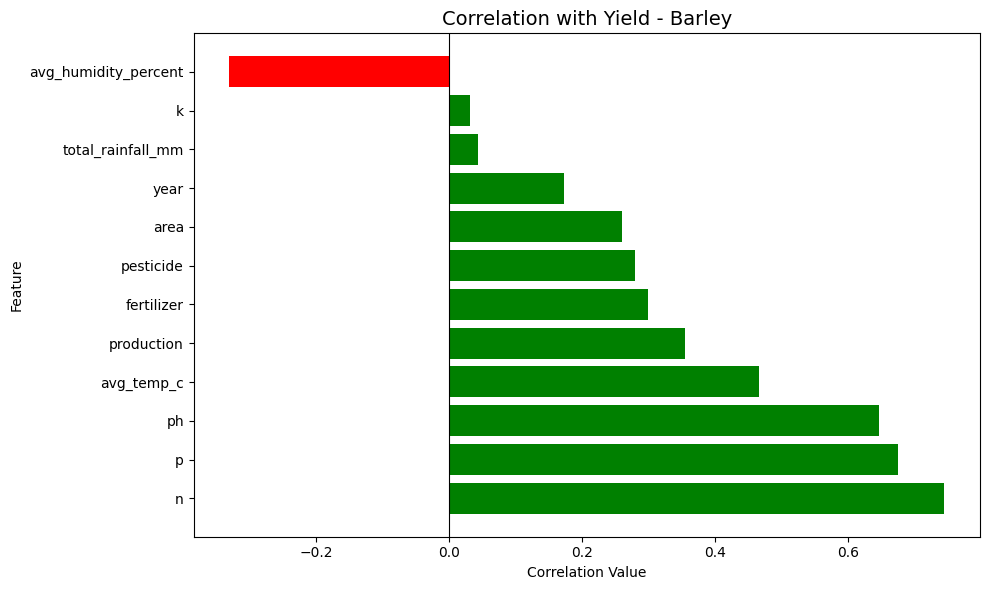

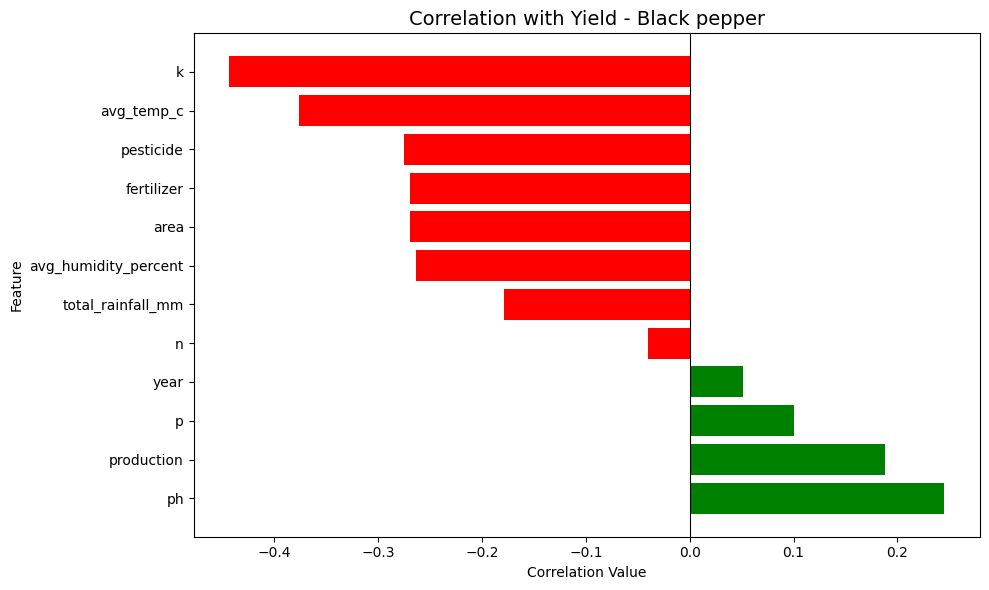

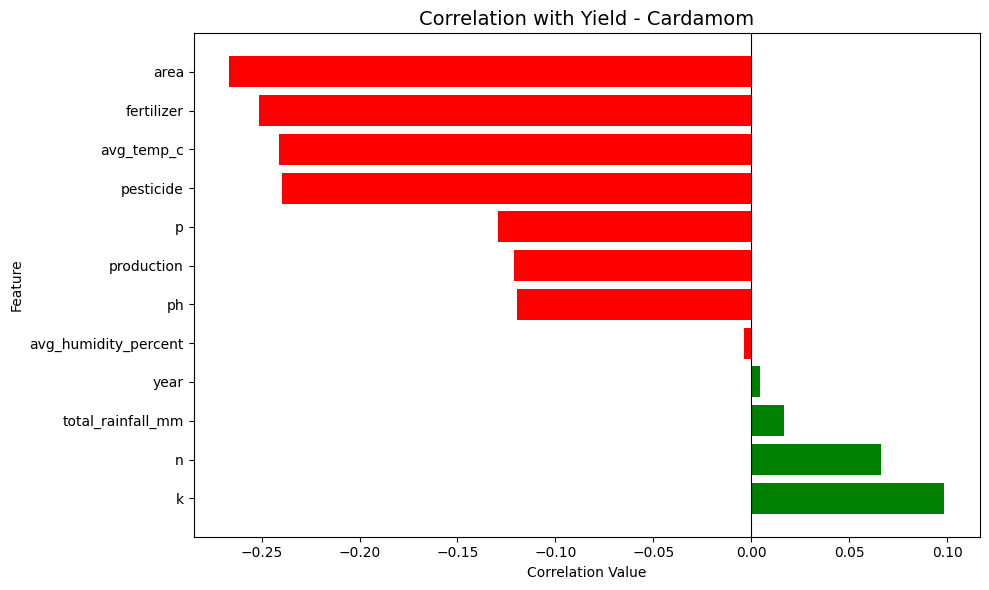

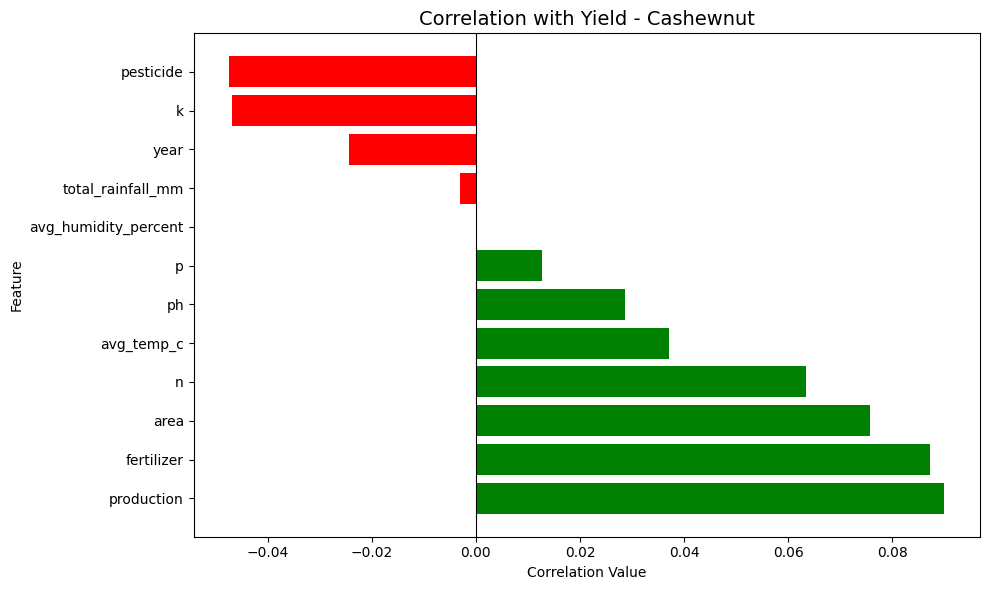

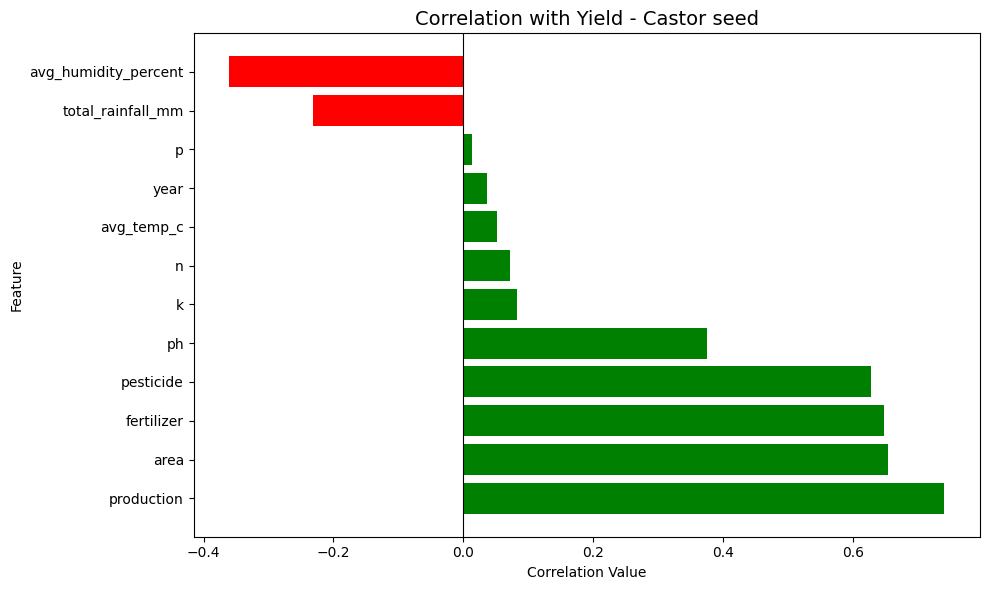

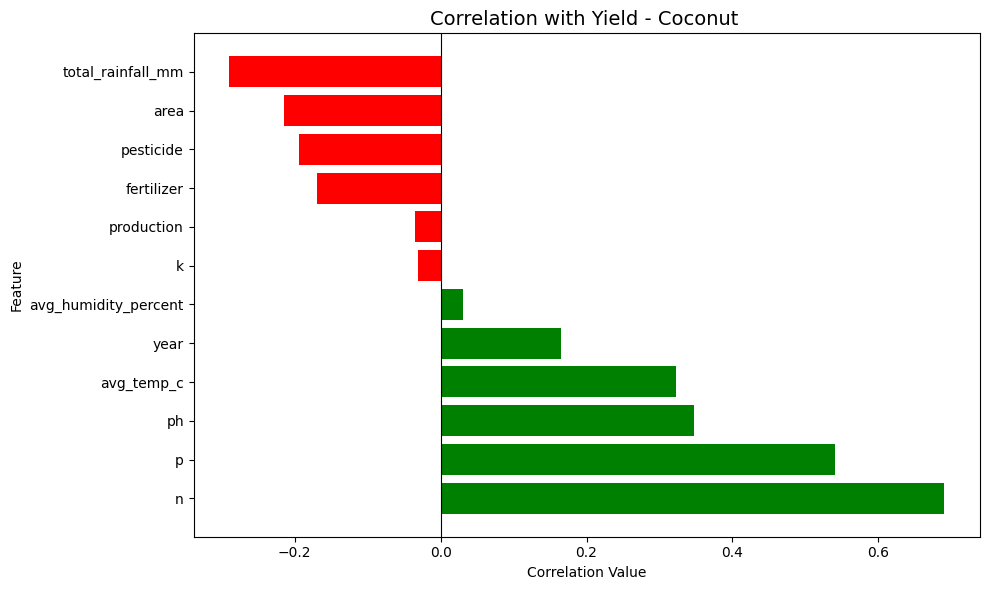

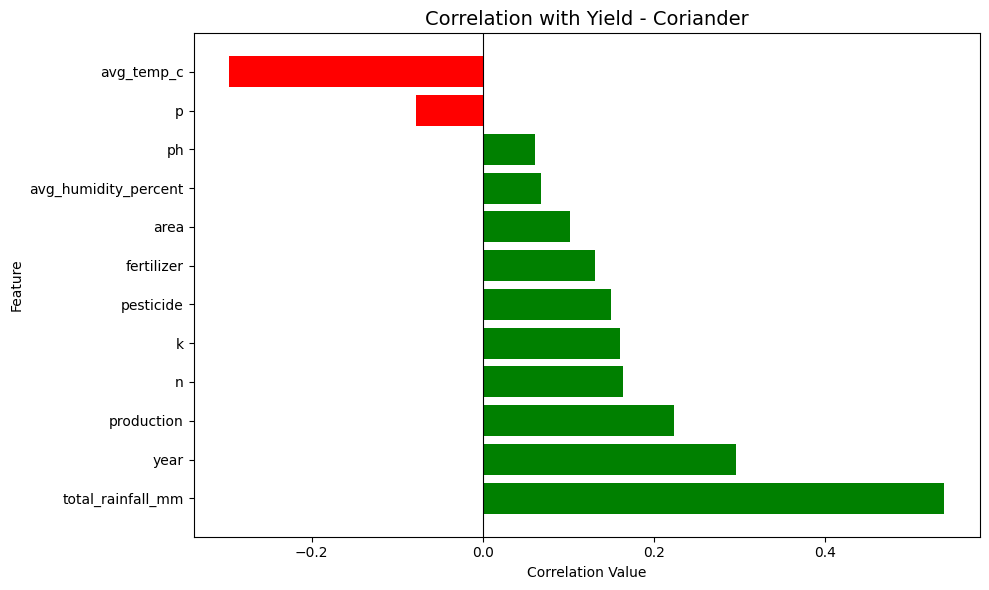

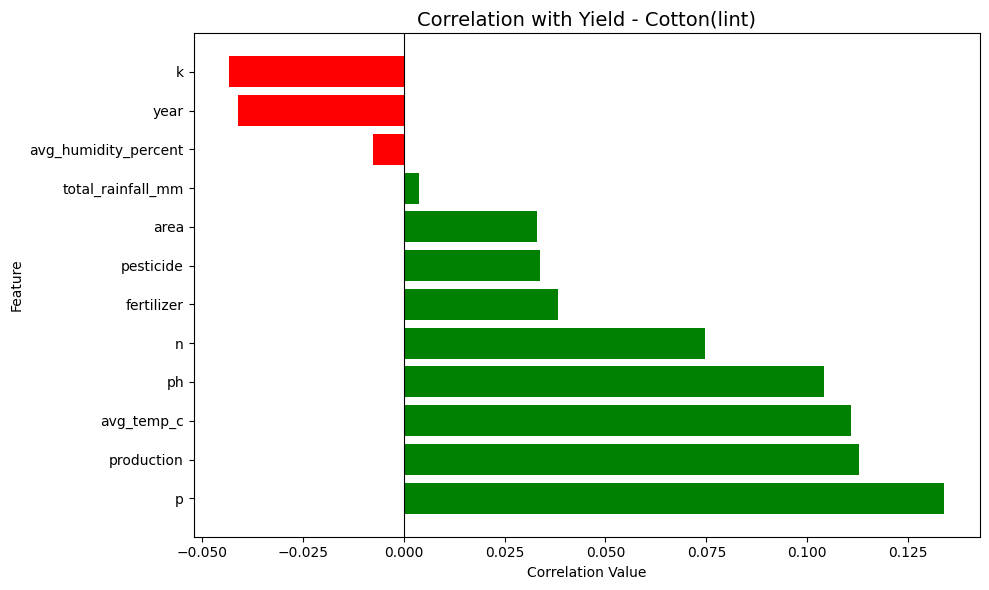

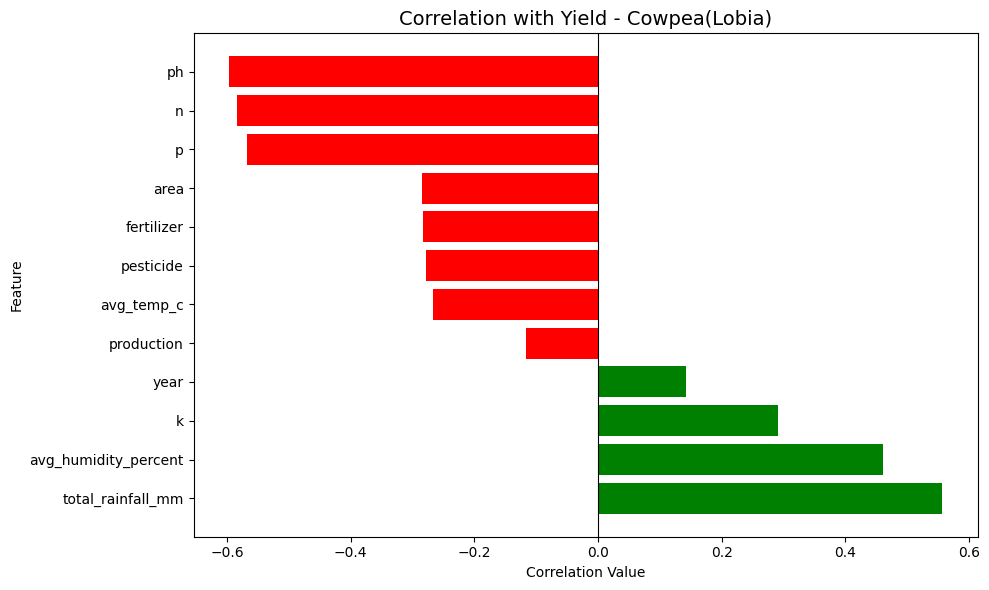

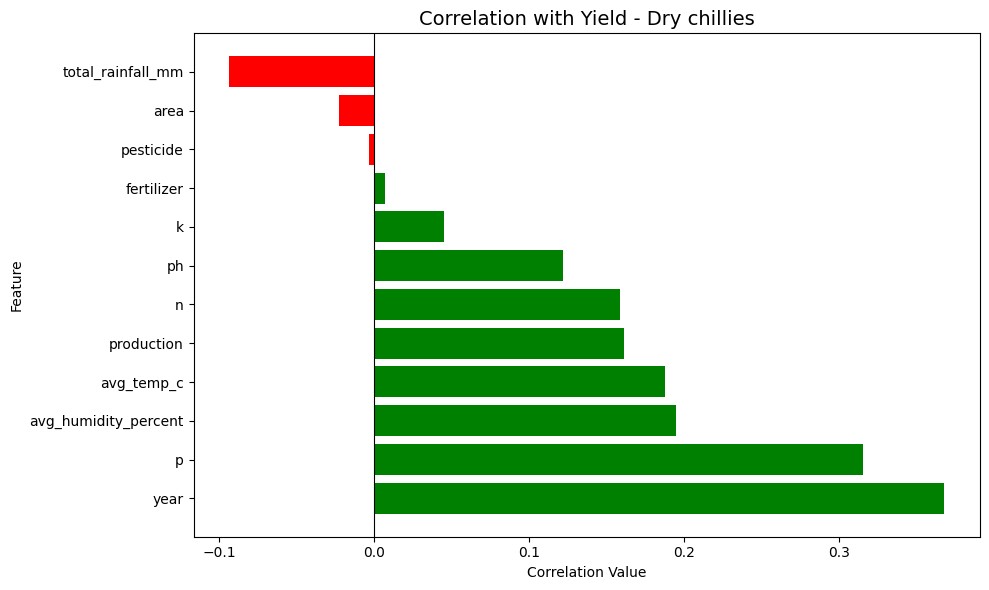

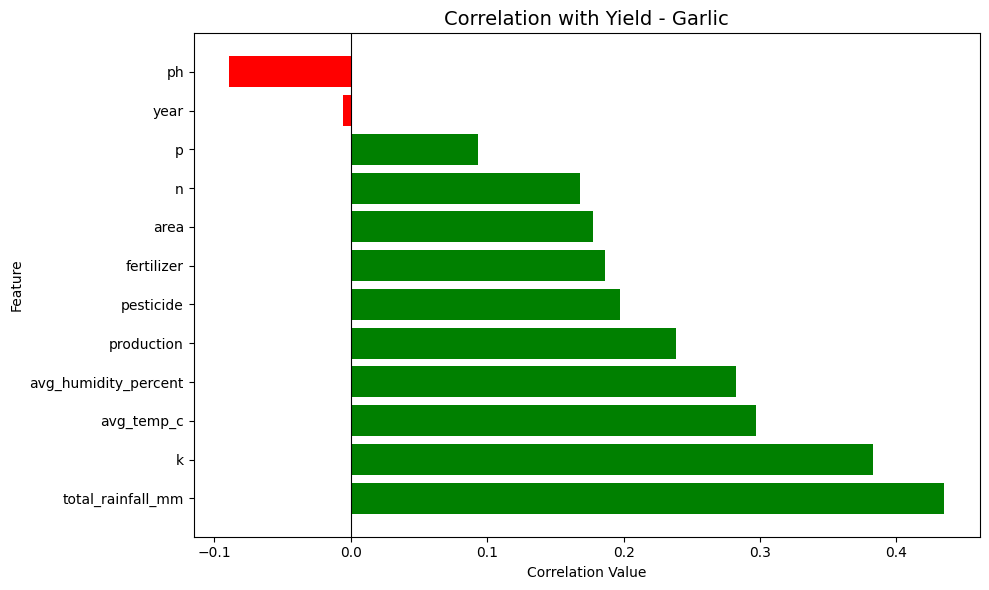

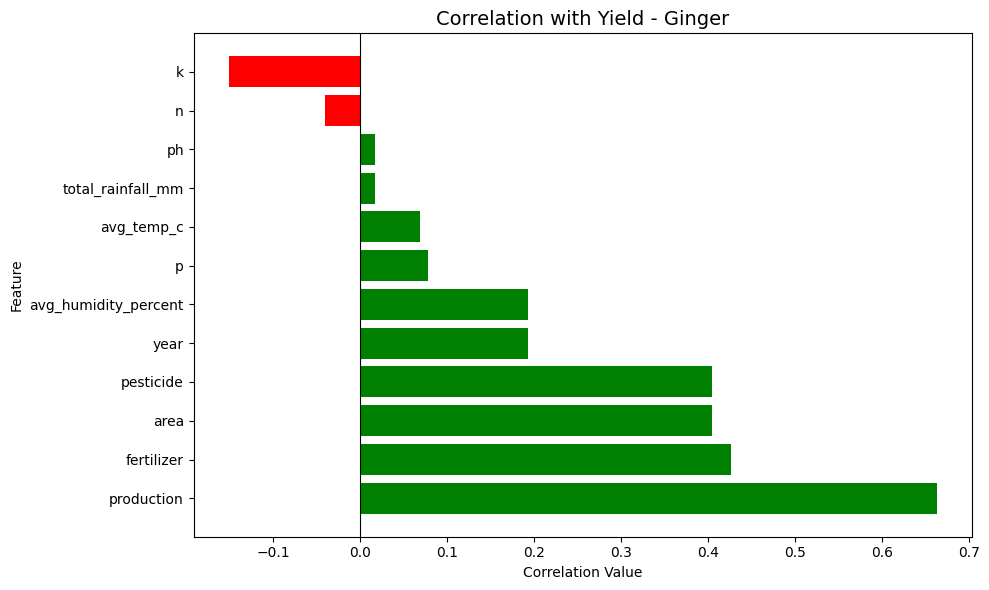

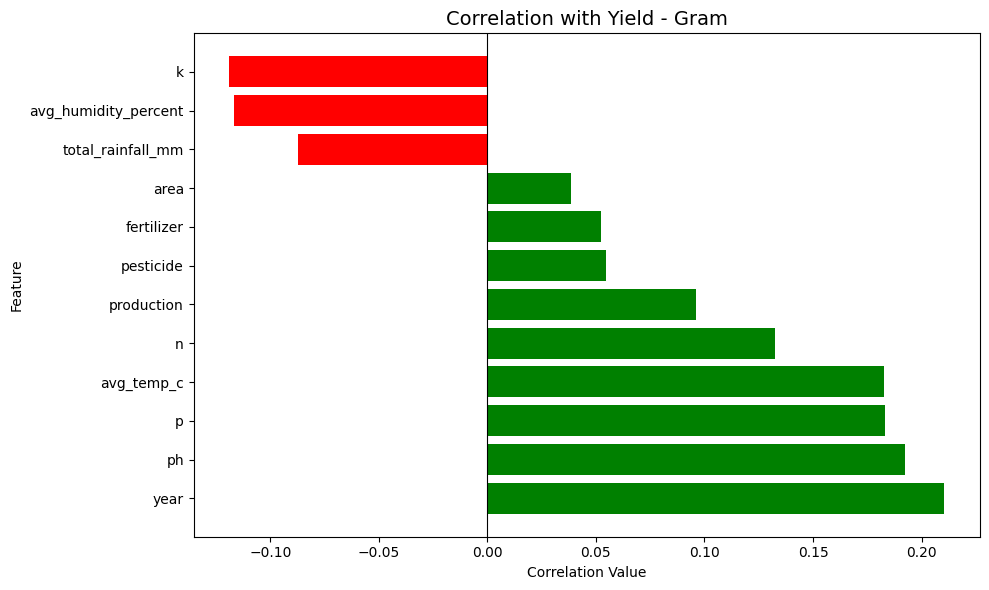

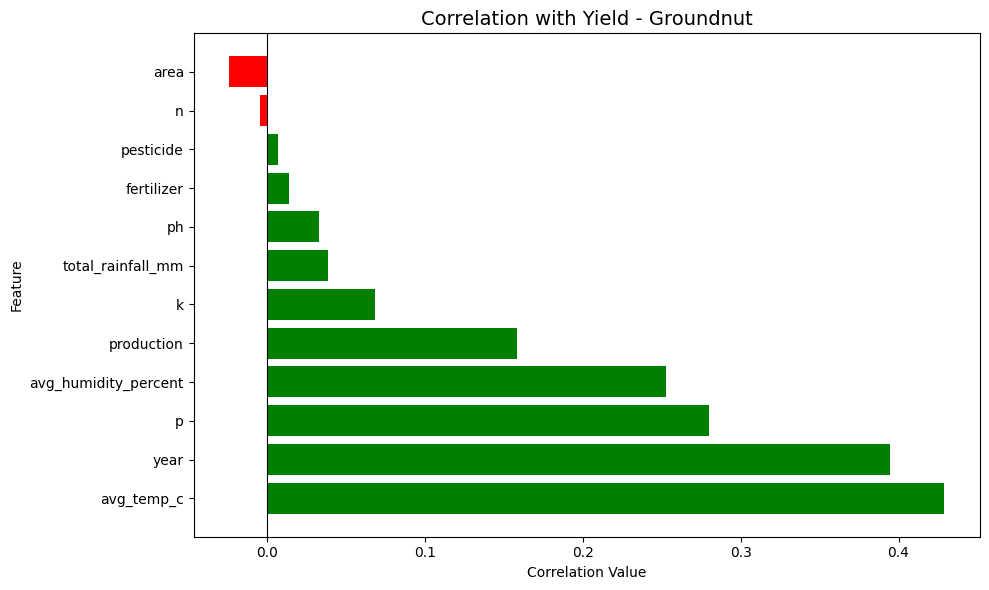

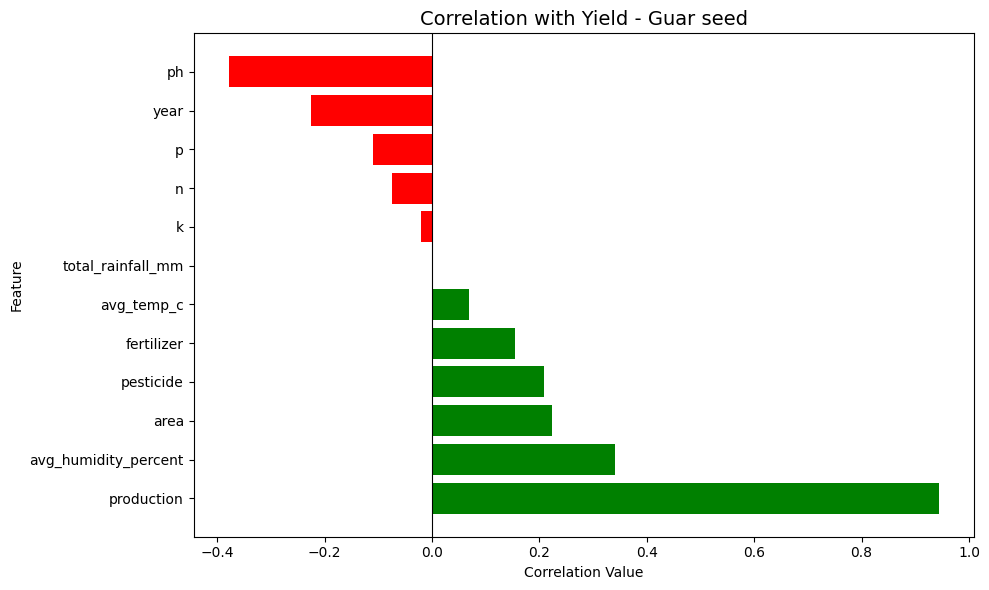

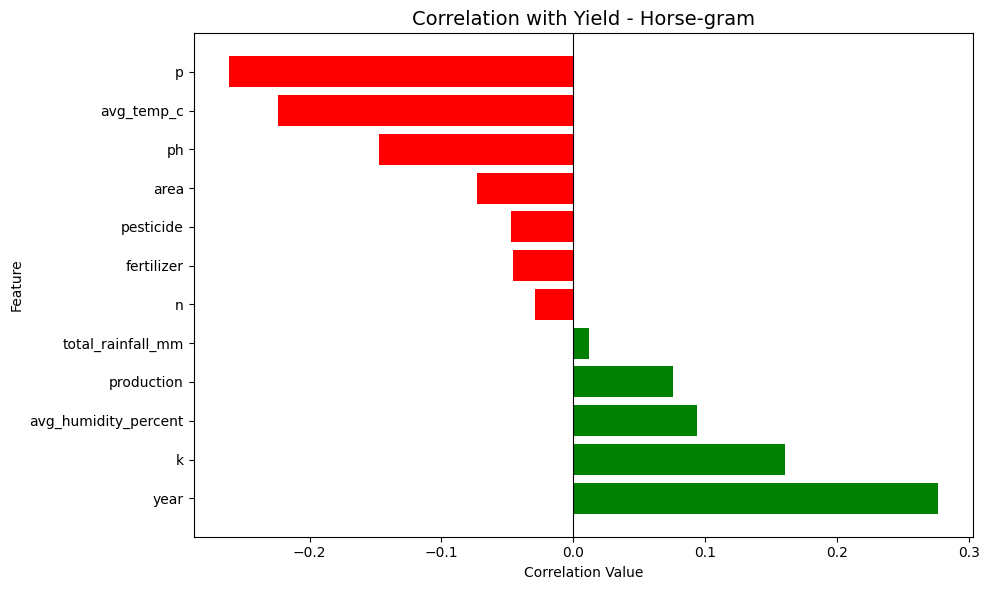

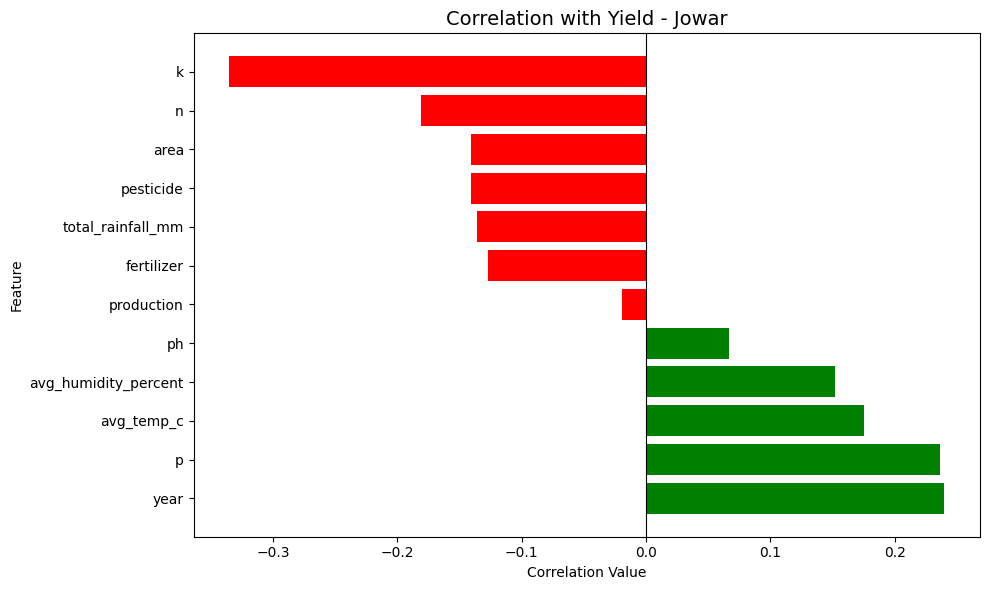

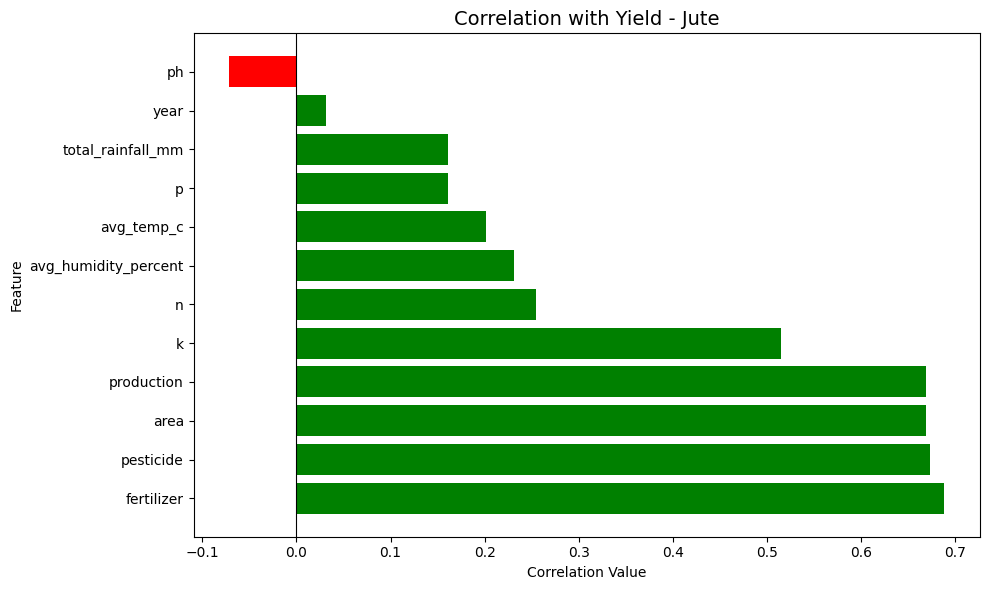

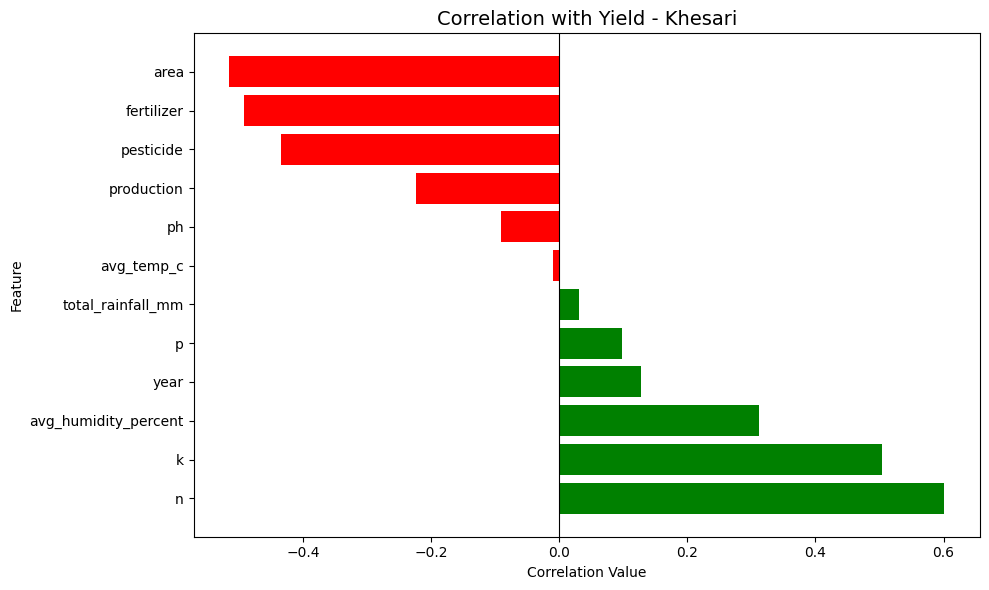

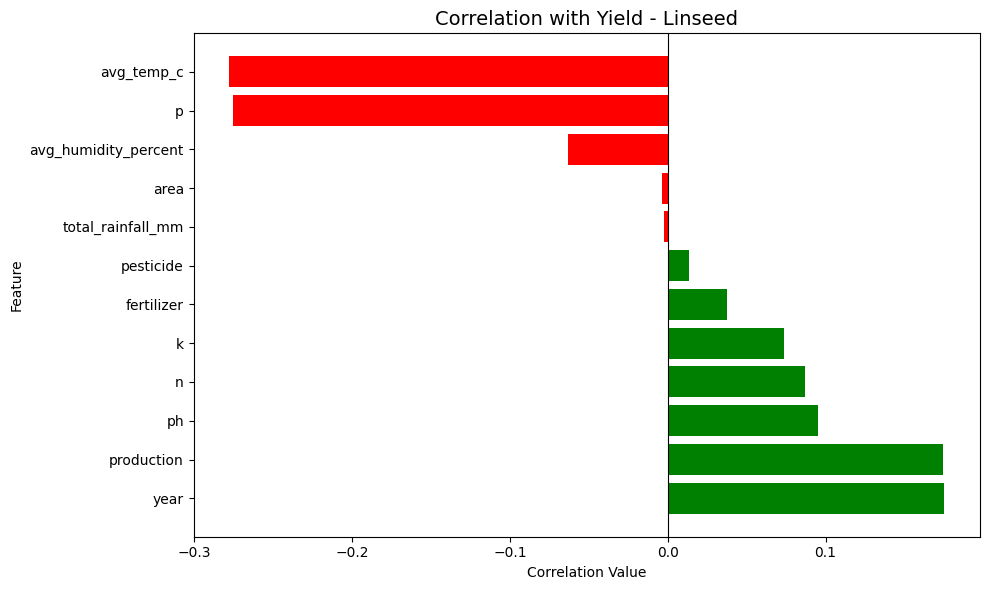

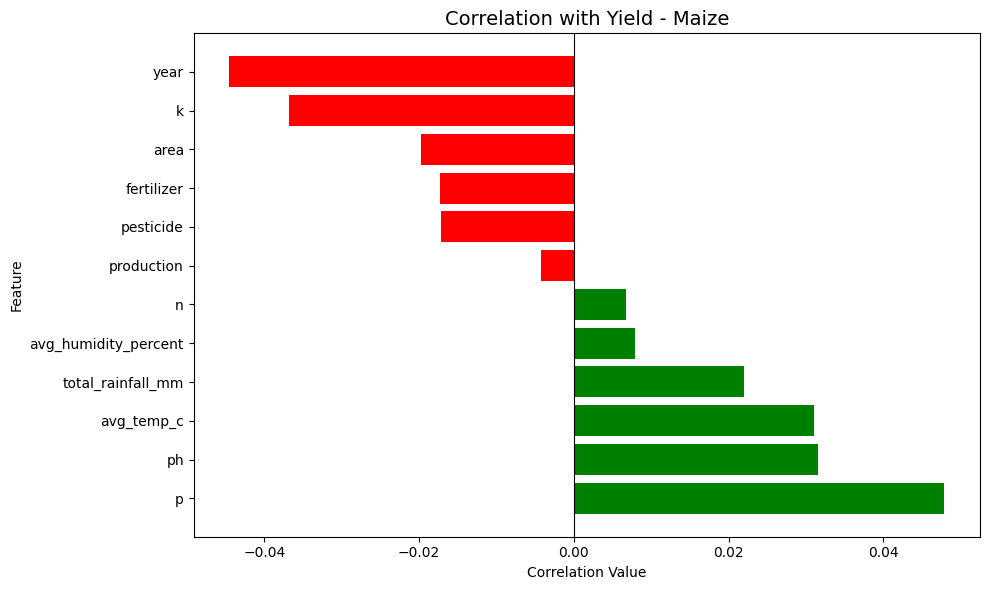

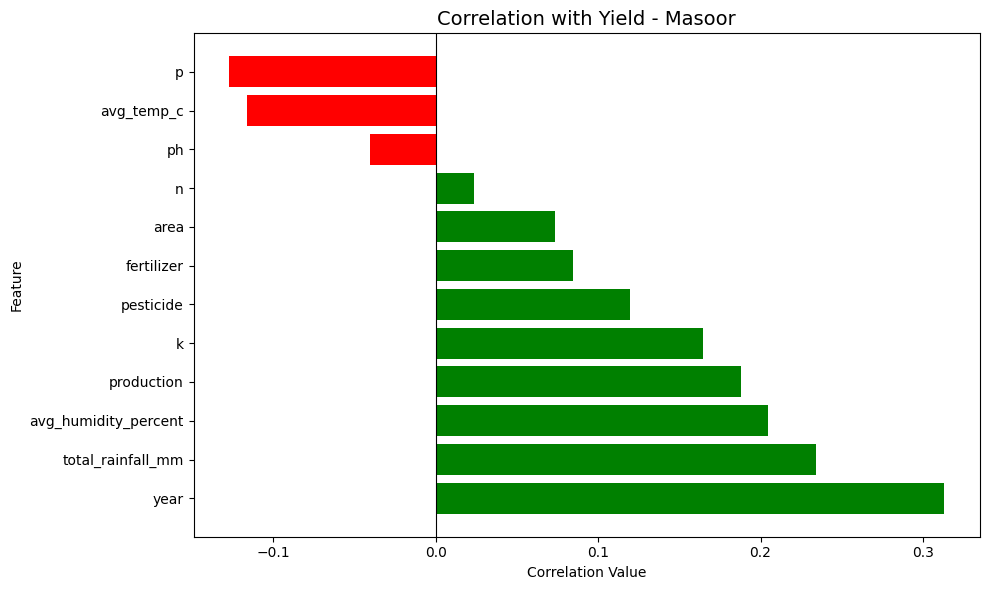

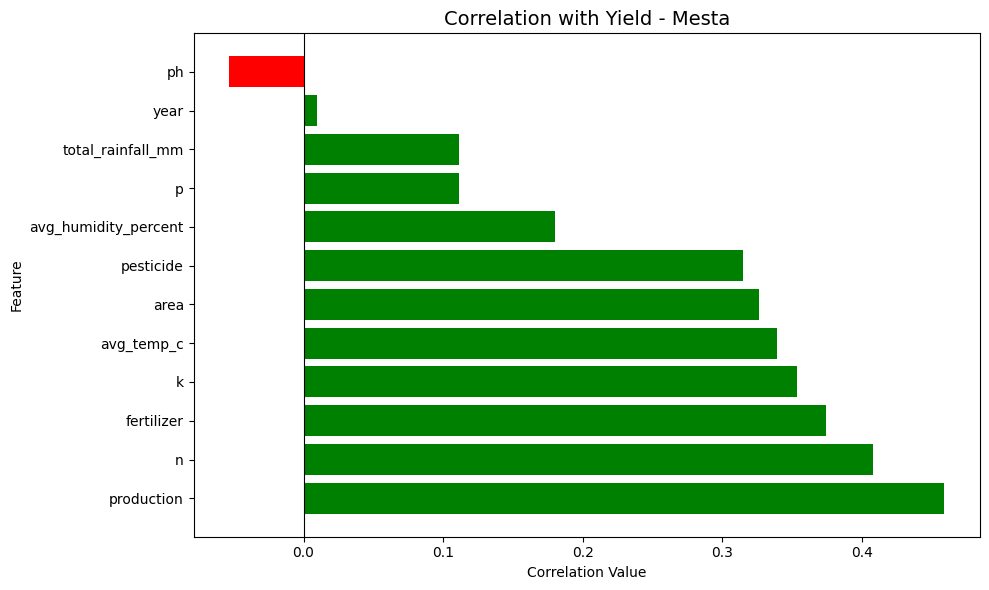

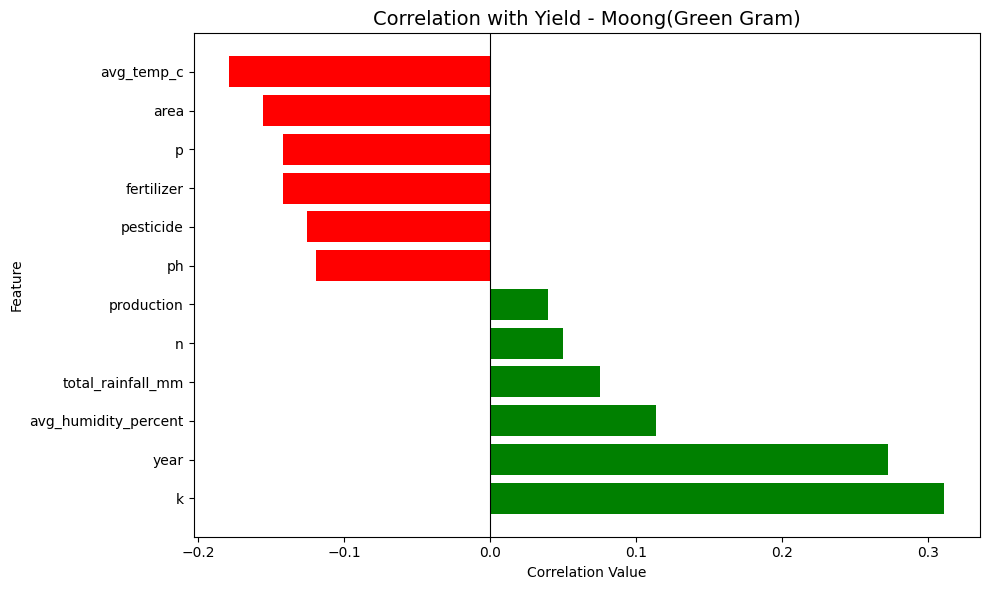

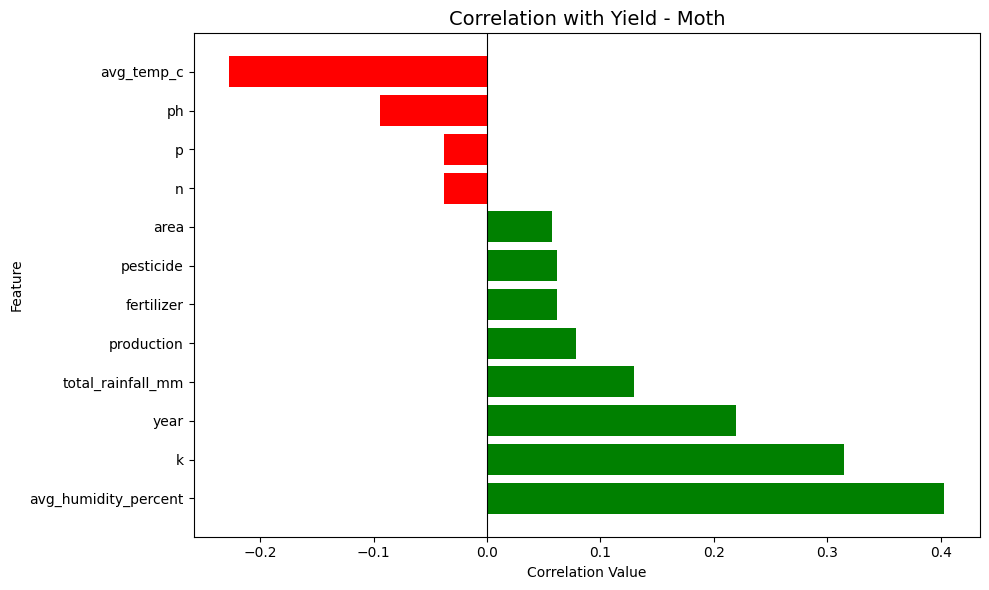

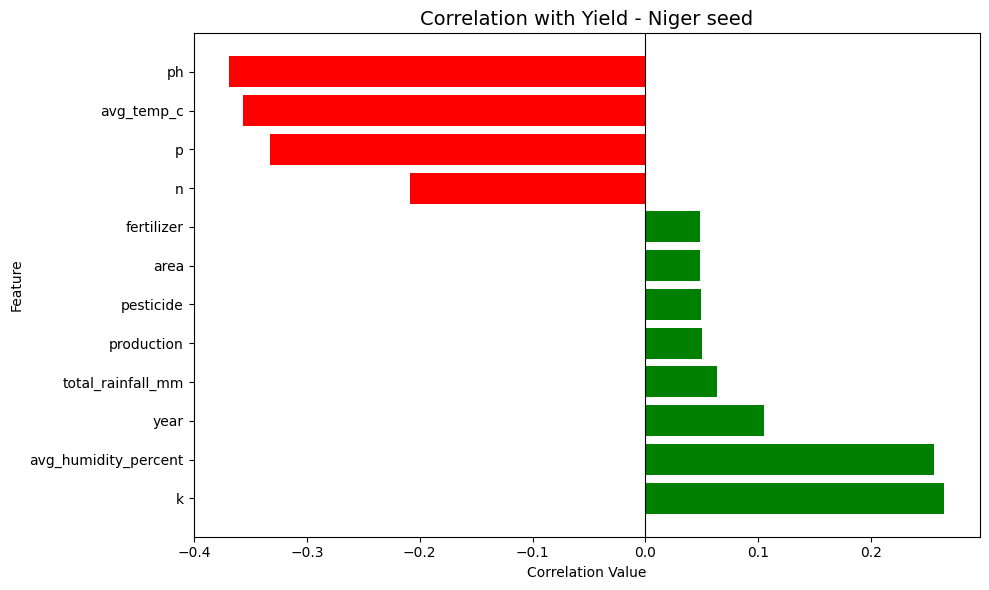

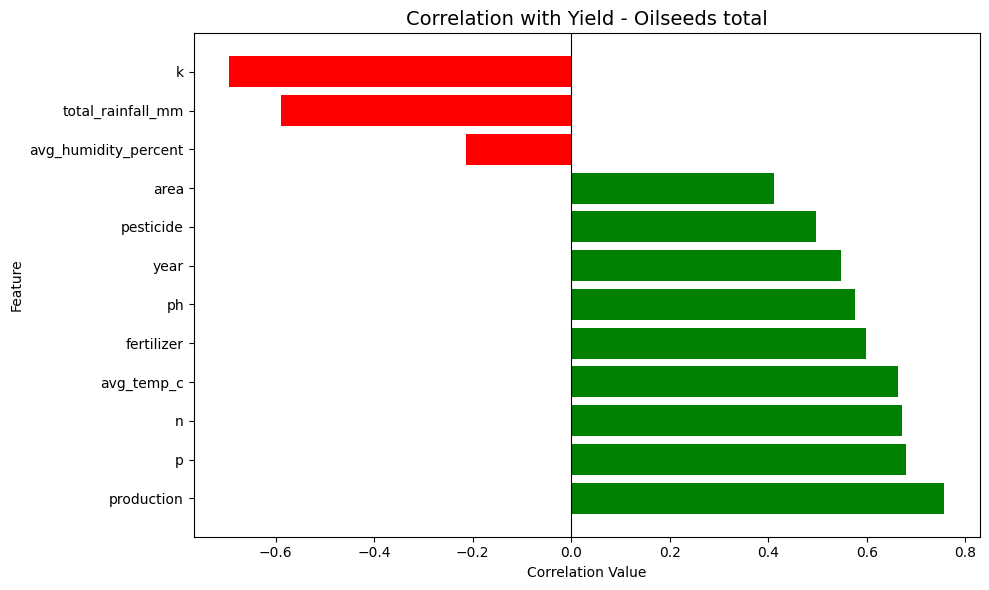

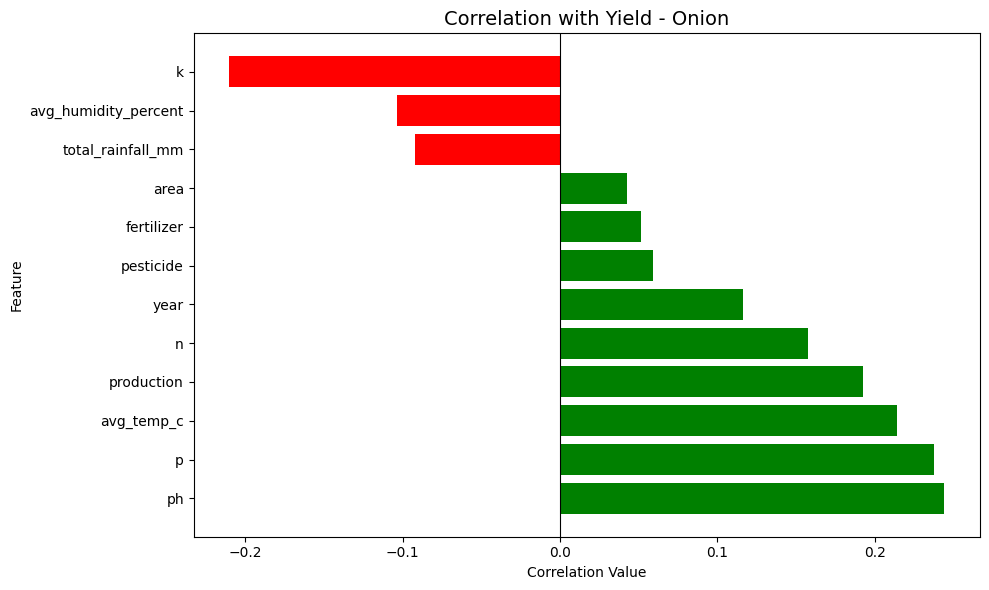

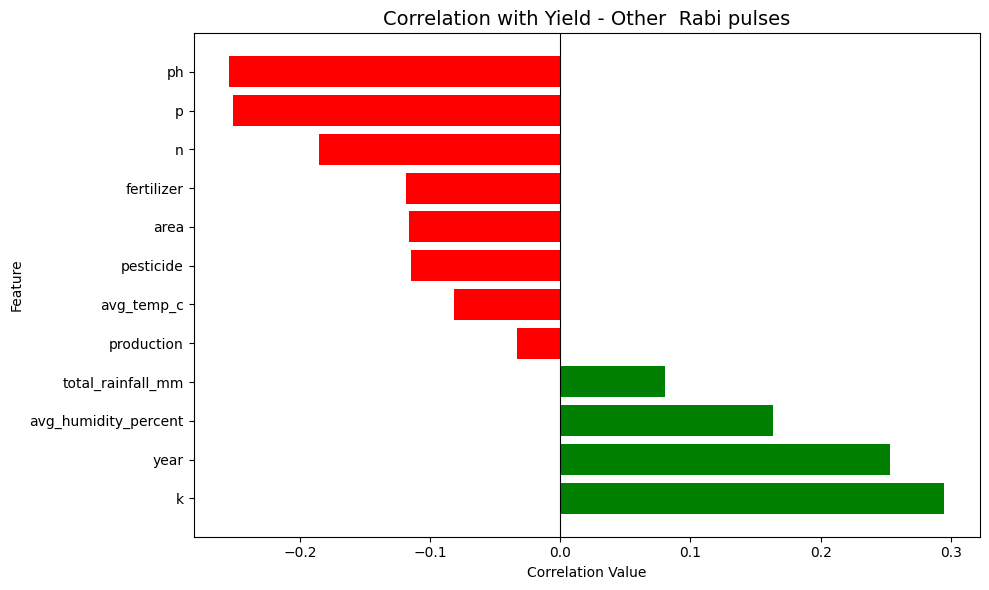

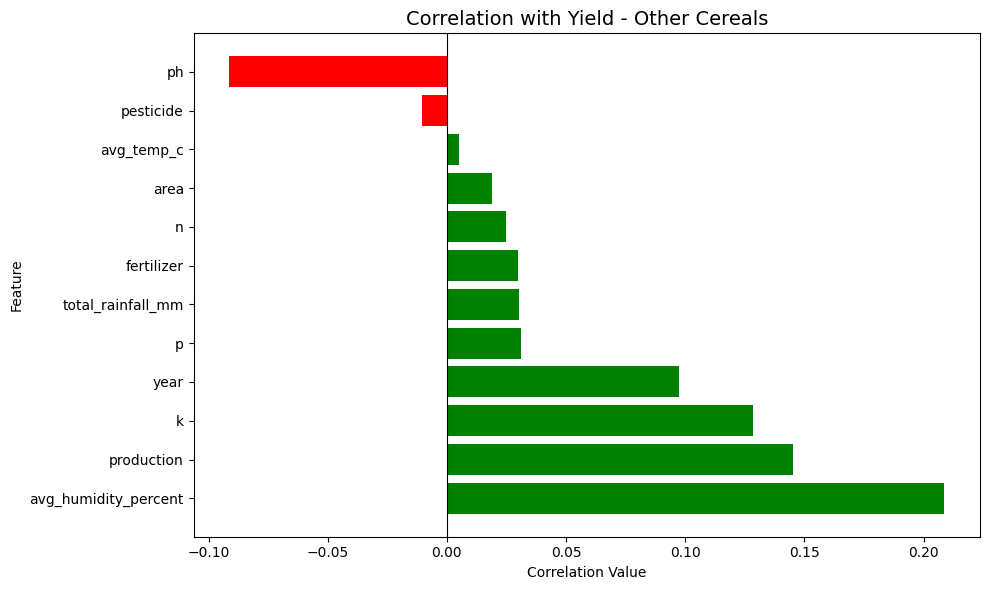

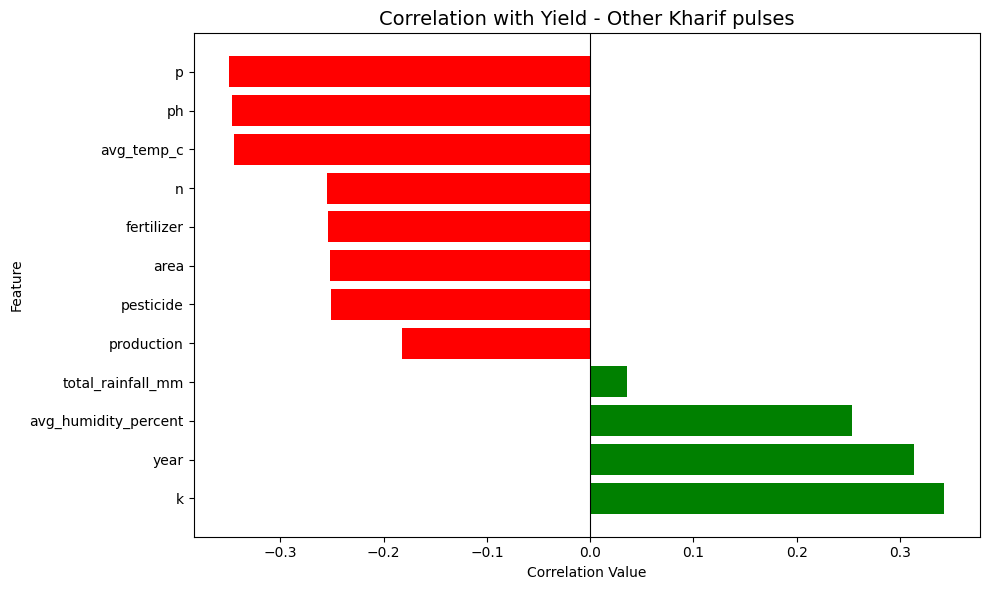

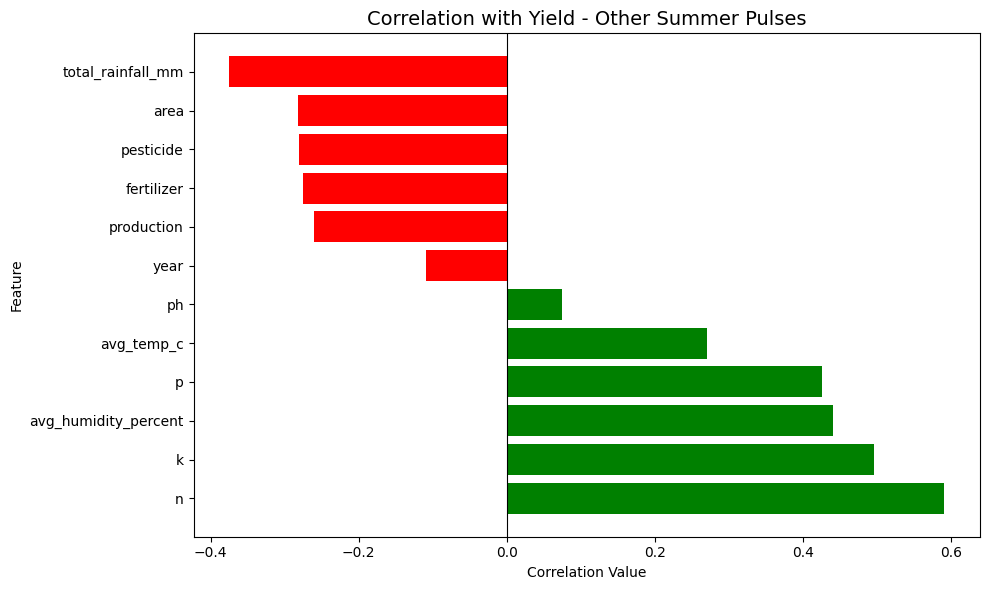

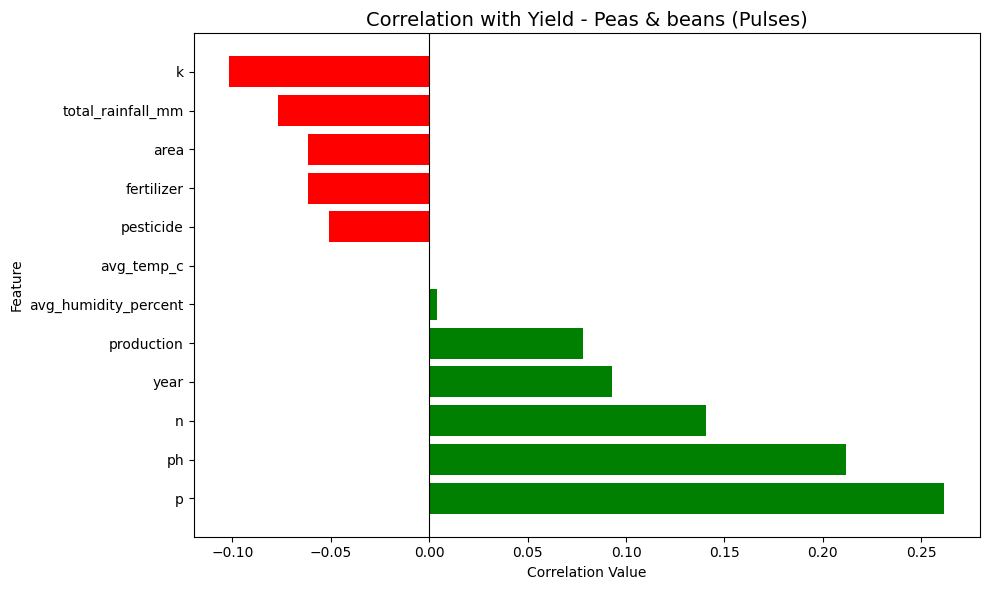

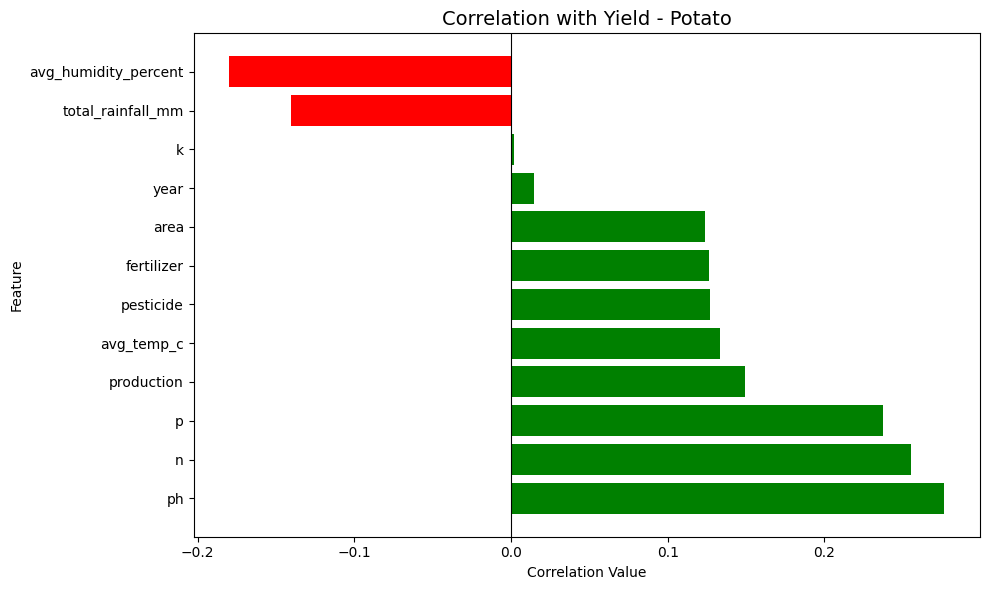

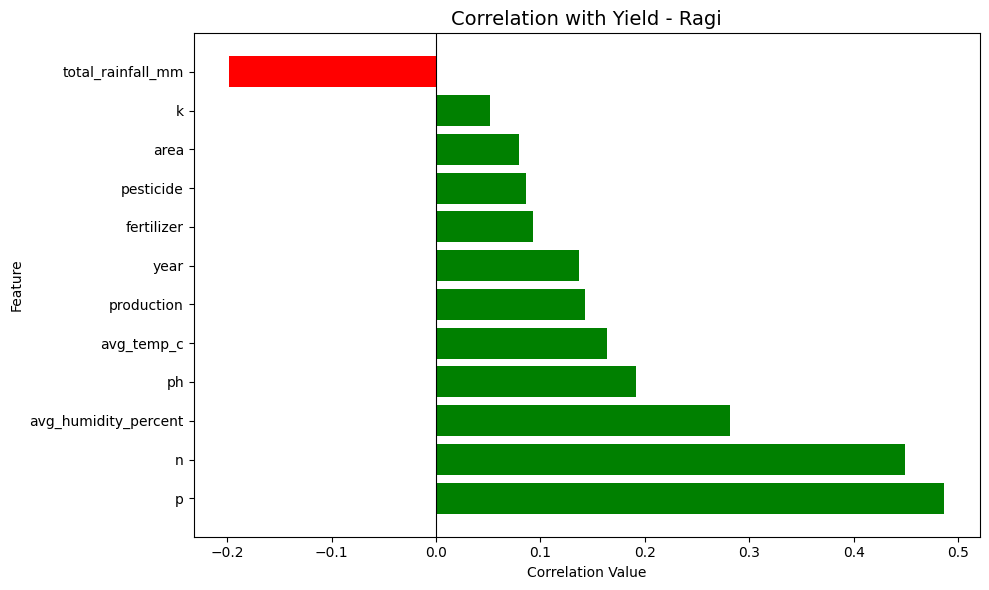

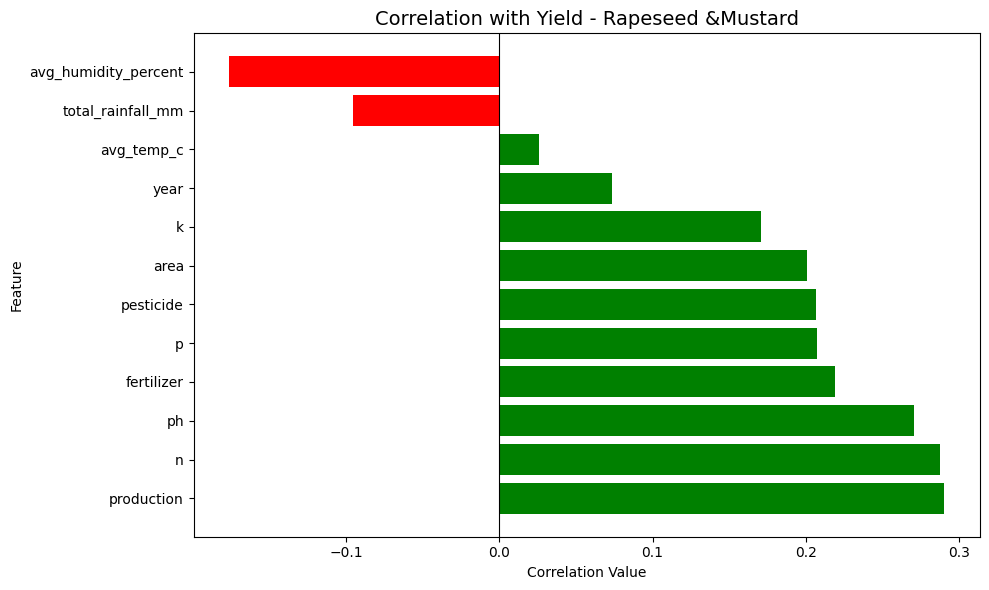

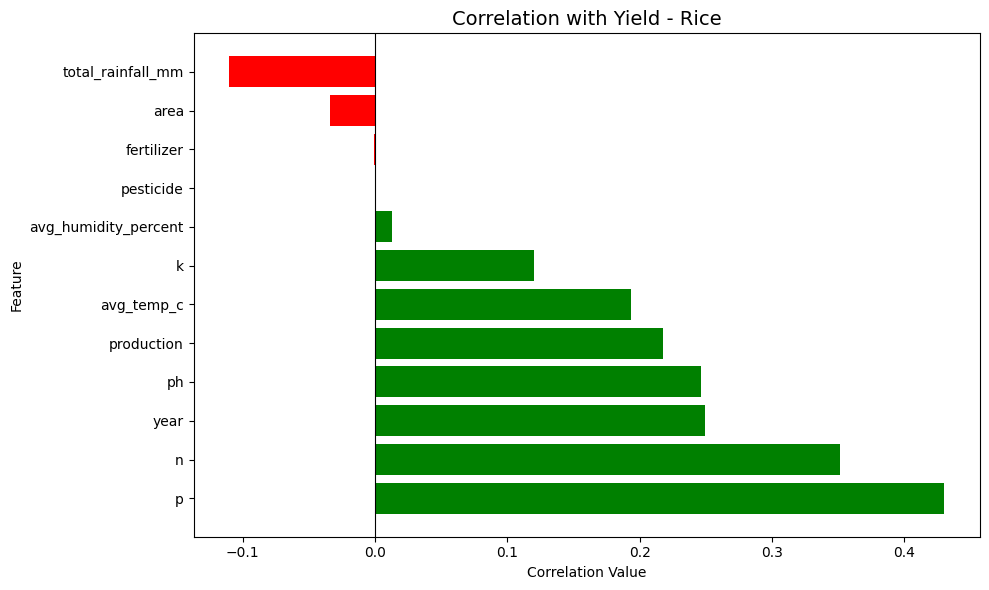

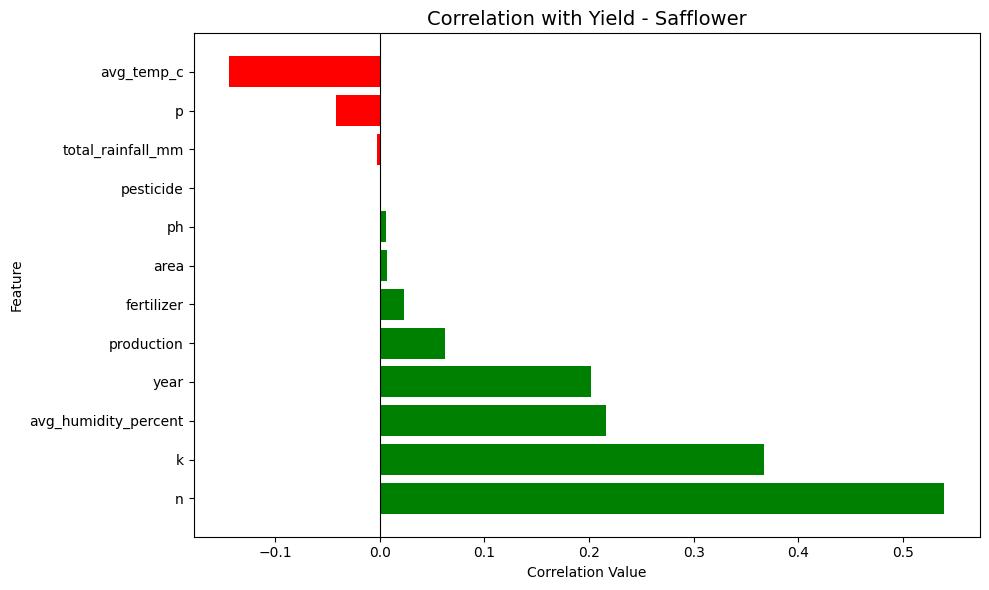

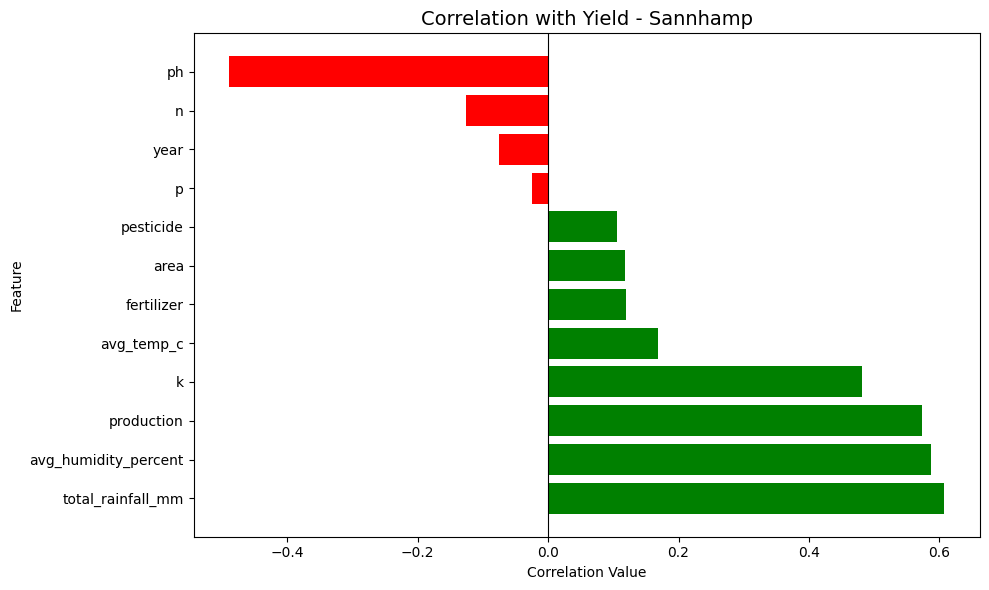

In [ ]:
import matplotlib.pyplot as plt

# Visualization
print("\n📊 Visualizing Correlations:\n")
for crop, group in merged.groupby("crop"):
    if "yield" not in group: 
        continue
    
    # Compute correlations
    corr = group.select_dtypes("number").corr()["yield"].drop("yield")
    if corr.empty:
        continue
    
    # Sort correlations
    corr_sorted = corr.sort_values(ascending=False)
    
    # Color coding: green for positive, red for negative
    colors = ["green" if v > 0 else "red" for v in corr_sorted]
     # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
    plt.title(f"Correlation with Yield - {crop}", fontsize=14)
    plt.xlabel("Correlation Value")
    plt.ylabel("Feature")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()